In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

## Loading data

#### Mission data (for metrics for EQ2, EQ3, EQ4)

In [2]:

mission_data_df = pd.read_csv("../output/multi-mission/atstart-income/mission_data.csv")
mission_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,makespan,robot_id,robot_idle_time
0,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_1,432.463462
1,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_2,613.922739
2,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_3,987.027707
3,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_4,957.081356
4,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_5,981.072034
...,...,...,...,...,...,...,...,...,...
607,test-multi_2_10_t_cleaning_i2_bl1,2,10,2,cleaning,bl1,487.509597,robot_2,299.933713
608,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,120.020152,robot_1,34.507760
609,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,120.020152,robot_2,74.994749
610,test-multi_2_20_t_cleaning_i1_multi3,2,20,1,cleaning,multi3,588.012671,robot_1,6.026476


#### Execution data (for metrics for EQ1)

In [3]:
with open("../output/multi-mission/atstart-income/execution_check_results.json", 'r') as f:
    execution_data = json.load(f)

rows = []
for test_name, details in execution_data["mission_details"].items():
    labels = test_name.split("_")
    robot_count = int(labels[1])
    mission_size = int(labels[2])
    inv_id = int(labels[5][1])
    scenario = labels[4]
    mode = labels[6]
    row = {
        "test_id": test_name,
        "robot_count": robot_count,
        "mission_size": mission_size,
        "inventory_id": inv_id,
        "scenario": scenario,
        "mode": mode,
        "constrained_tasks": details["this_test_checks"],
        "respected_constraints": details["checks_passed"],
        "failed_constraints": details["checks_failed"],
        "test_result": details["test_ok"]
    }
    rows.append(row)

execution_data_df = pd.DataFrame(rows)
execution_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,constrained_tasks,respected_constraints,failed_constraints,test_result
0,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,40,40,0,True
1,test-multi_10_20_t_cleaning_i0_multi3,10,20,0,cleaning,multi3,36,36,0,True
2,test-multi_10_10_t_cleaning_i0_bl1,10,10,0,cleaning,bl1,20,20,0,True
3,test-multi_5_10_t_cleaning_i1_bl2,5,10,1,cleaning,bl2,20,20,0,True
4,test-multi_10_20_t_cleaning_i1_bl1,10,20,1,cleaning,bl1,40,40,0,True
...,...,...,...,...,...,...,...,...,...,...
103,test-multi_10_2_t_cleaning_i0_bl1,10,2,0,cleaning,bl1,4,4,0,True
104,test-multi_10_2_t_cleaning_i0_bl0,10,2,0,cleaning,bl0,4,4,0,True
105,test-multi_2_10_t_cleaning_i2_bl1,2,10,2,cleaning,bl1,20,20,0,True
106,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,4,4,0,True


## EQ1: Task order compliance

#### Metrics

Order satisfaction ratio:

$TOCR = \frac{1}{|\mathcal{O}|}\sum_{(t_i,t_j)\in\mathcal{O}} %\mathbf{1}_{end(t_i)\leq start(t_j)},
    \begin{cases}
    1 & \text{if  } end(t_i)\leq start(t_j) \\
    0 & \text{otherwise}
    \end{cases}
$

In [4]:
execution_data_df["tocr"] = execution_data_df["respected_constraints"] / execution_data_df["constrained_tasks"]
execution_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,constrained_tasks,respected_constraints,failed_constraints,test_result,tocr
0,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,40,40,0,True,1.0
1,test-multi_10_20_t_cleaning_i0_multi3,10,20,0,cleaning,multi3,36,36,0,True,1.0
2,test-multi_10_10_t_cleaning_i0_bl1,10,10,0,cleaning,bl1,20,20,0,True,1.0
3,test-multi_5_10_t_cleaning_i1_bl2,5,10,1,cleaning,bl2,20,20,0,True,1.0
4,test-multi_10_20_t_cleaning_i1_bl1,10,20,1,cleaning,bl1,40,40,0,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...
103,test-multi_10_2_t_cleaning_i0_bl1,10,2,0,cleaning,bl1,4,4,0,True,1.0
104,test-multi_10_2_t_cleaning_i0_bl0,10,2,0,cleaning,bl0,4,4,0,True,1.0
105,test-multi_2_10_t_cleaning_i2_bl1,2,10,2,cleaning,bl1,20,20,0,True,1.0
106,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,4,4,0,True,1.0


In [5]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_baseline = execution_data_df[execution_data_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_baseline_avg = (
    df_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "constrained_tasks": "mean",
        "respected_constraints": "mean",
        "failed_constraints": "mean",
        "tocr": "mean"
    })
)

df_baseline_avg["mode"] = "baseline"

df_multi3 = execution_data_df[execution_data_df["mode"] == "multi3"].copy()

df_grouped = pd.concat([df_baseline_avg, df_multi3], ignore_index=True)

df_grouped = df_grouped[group_cols + ["mode", "constrained_tasks", "respected_constraints", "failed_constraints", "tocr"]]
df_grouped

,scenario,robot_count,mission_size,inventory_id,mode,constrained_tasks,respected_constraints,failed_constraints,tocr
0,cleaning,2,2,0,baseline,4.000000,4.000000,0.0,1.0
1,cleaning,2,2,1,baseline,4.000000,4.000000,0.0,1.0
2,cleaning,2,2,2,baseline,4.000000,4.000000,0.0,1.0
3,cleaning,2,10,0,baseline,20.000000,20.000000,0.0,1.0
4,cleaning,2,10,1,baseline,20.000000,20.000000,0.0,1.0
5,cleaning,2,10,2,baseline,20.000000,20.000000,0.0,1.0
6,cleaning,2,20,0,baseline,39.000000,39.000000,0.0,1.0
7,cleaning,2,20,1,baseline,38.000000,38.000000,0.0,1.0
8,cleaning,2,20,2,baseline,40.000000,40.000000,0.0,1.0
9,cleaning,5,2,0,baseline,4.000000,4.000000,0.0,1.0


In [6]:
pivot_df = df_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["constrained_tasks", "respected_constraints", "failed_constraints", "tocr"]
)

pivot_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_df.columns]

pivot_df = pivot_df.reset_index()
pivot_df

,scenario,robot_count,mission_size,inventory_id,constrained_tasks_baseline,constrained_tasks_multi3,failed_constraints_baseline,failed_constraints_multi3,respected_constraints_baseline,respected_constraints_multi3,tocr_baseline,tocr_multi3
0,cleaning,2,2,0,4.000000,4.0,0.0,0.0,4.000000,4.0,1.0,1.0
1,cleaning,2,2,1,4.000000,4.0,0.0,0.0,4.000000,4.0,1.0,1.0
2,cleaning,2,2,2,4.000000,4.0,0.0,0.0,4.000000,4.0,1.0,1.0
3,cleaning,2,10,0,20.000000,20.0,0.0,0.0,20.000000,20.0,1.0,1.0
4,cleaning,2,10,1,20.000000,20.0,0.0,0.0,20.000000,20.0,1.0,1.0
5,cleaning,2,10,2,20.000000,20.0,0.0,0.0,20.000000,20.0,1.0,1.0
6,cleaning,2,20,0,39.000000,40.0,0.0,0.0,39.000000,40.0,1.0,1.0
7,cleaning,2,20,1,38.000000,40.0,0.0,0.0,38.000000,40.0,1.0,1.0
8,cleaning,2,20,2,40.000000,40.0,0.0,0.0,40.000000,40.0,1.0,1.0
9,cleaning,5,2,0,4.000000,4.0,0.0,0.0,4.000000,4.0,1.0,1.0


In [7]:
df_avg = (
    pivot_df
    .groupby("scenario", as_index=False)
    .agg({
        "tocr_baseline": "mean",
        "tocr_multi3": "mean",
    })
)

df_avg["tocr_diff_percentage"] = ((df_avg["tocr_multi3"] - df_avg["tocr_baseline"]) / df_avg["tocr_baseline"]) *100

df_avg

,scenario,tocr_baseline,tocr_multi3,tocr_diff_percentage
0,cleaning,1.0,1.0,0.0


## EQ2: Mission completion time analysis

#### Data report

In [8]:
df_mission = (
    mission_data_df.groupby("test_id")
      .agg({
          "robot_count": "first",
          "mission_size": "first",
          "inventory_id": "first",
          "scenario": "first",
          "mode": "first",
          "makespan": "first",
          "robot_idle_time": "mean"
      })
      .reset_index()
)

df_mission.rename(columns={"robot_idle_time": "average_robot_idle_time"}, inplace=True)
df_mission = df_mission[["scenario", "robot_count", "mission_size", "inventory_id", "mode", "makespan", "average_robot_idle_time"]]

df_mission

,scenario,robot_count,mission_size,inventory_id,mode,makespan,average_robot_idle_time
0,cleaning,10,10,0,bl0,493.506086,440.933184
1,cleaning,10,10,0,bl1,489.049393,437.210824
2,cleaning,10,10,0,bl2,492.051409,439.254687
3,cleaning,10,10,0,multi3,93.055387,44.341199
4,cleaning,10,10,1,bl0,456.048517,407.513430
...,...,...,...,...,...,...,...
103,cleaning,5,2,1,multi3,70.504082,46.818695
104,cleaning,5,2,2,bl0,94.504895,71.699690
105,cleaning,5,2,2,bl1,90.029824,67.831125
106,cleaning,5,2,2,bl2,90.037024,67.551622


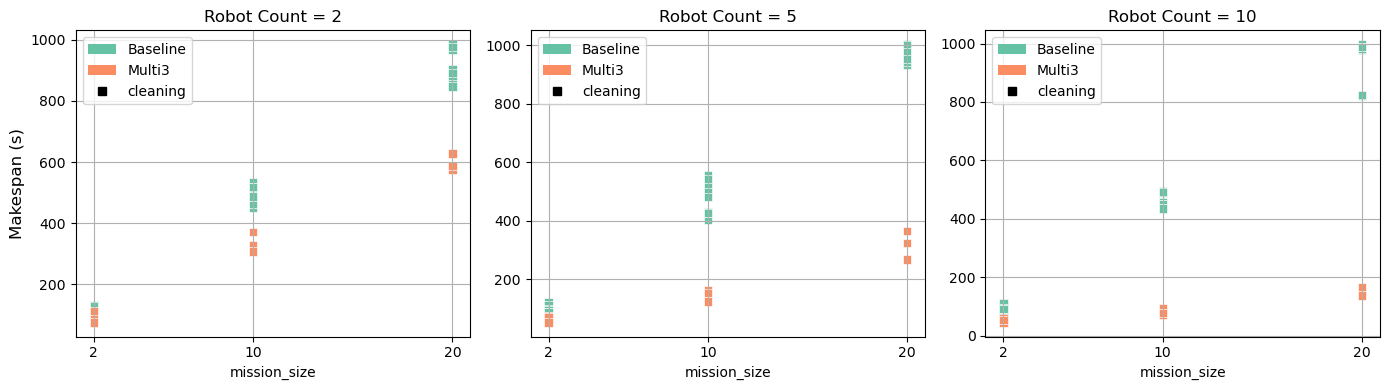

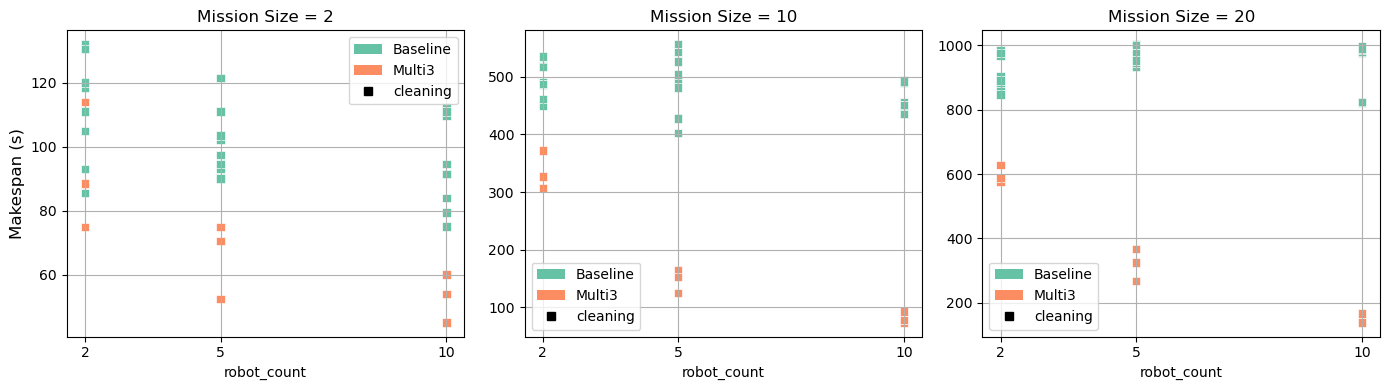

In [9]:
def multiplot(df,fname,external_variable,var_x,var_y,title,x_label,y_label):
    marker_dict = {
        'agriculture': 'o',
        'cleaning': 's',
        'logistics': '^',
        'surveillance': 'D',
        'other': 'v'
    }
    palette = sns.color_palette("Set2")
    approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for i, v in enumerate(external_variable_values):
        x_df = df[(df[external_variable] == v)][[var_x,var_y,"mode","scenario"]]
        bl_df = x_df[(x_df["mode"] == "bl0") | (x_df["mode"] == "bl1") | (x_df["mode"] == "bl2")]

        m3_df = x_df[x_df["mode"] == "multi3"]

        sns.scatterplot(data=bl_df, x=var_x, y=var_y, style='scenario', color=approach_colors['Baseline'], ax=axes[i], markers=marker_dict)
        sns.scatterplot(data=m3_df, x=var_x, y=var_y, style='scenario', color=approach_colors['Multi3'], ax=axes[i], markers=marker_dict)

        axes[i].set_title(title.replace("$field$",str(v)))
        if i == 0:
            axes[i].set_ylabel(y_label, fontsize=12)
        else:
            axes[i].set_ylabel("")
        axes[i].set_xticks(sorted(x_df[var_x].unique()))
        
        color_handles = [
            Patch(facecolor=approach_colors['Baseline'], label='Baseline'),
            Patch(facecolor=approach_colors['Multi3'], label='Multi3')
        ]

        marker_handles = [
            Line2D([0], [0], marker=marker_dict[s], color='black', linestyle='None', label=s) for s in df["scenario"].unique() 
        ]

        axes[i].legend(handles=color_handles + marker_handles)
        axes[i].grid()

    plt.tight_layout()
    plt.savefig(fname, format="pdf")
    plt.show()

multiplot(df_mission, "../output/multi-mission/atstart-income/images/ms_by_mission_size_scatter.pdf", "robot_count", "mission_size","makespan","Robot Count = $field$", "Mission Size", "Makespan (s)")
multiplot(df_mission, "../output/multi-mission/atstart-income/images/ms_by_robot_count_scatter.pdf", "mission_size", "robot_count","makespan","Mission Size = $field$", "Robot Count", "Makespan (s)")

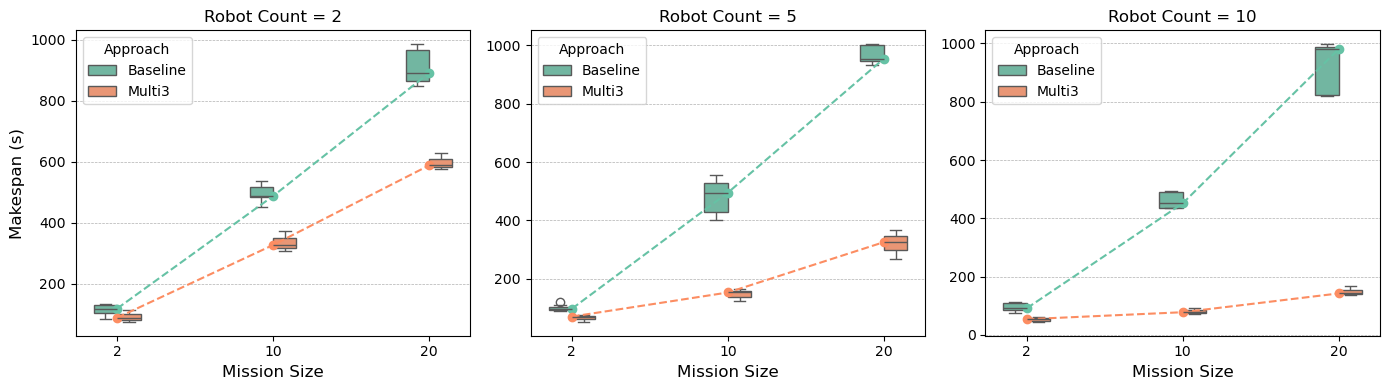

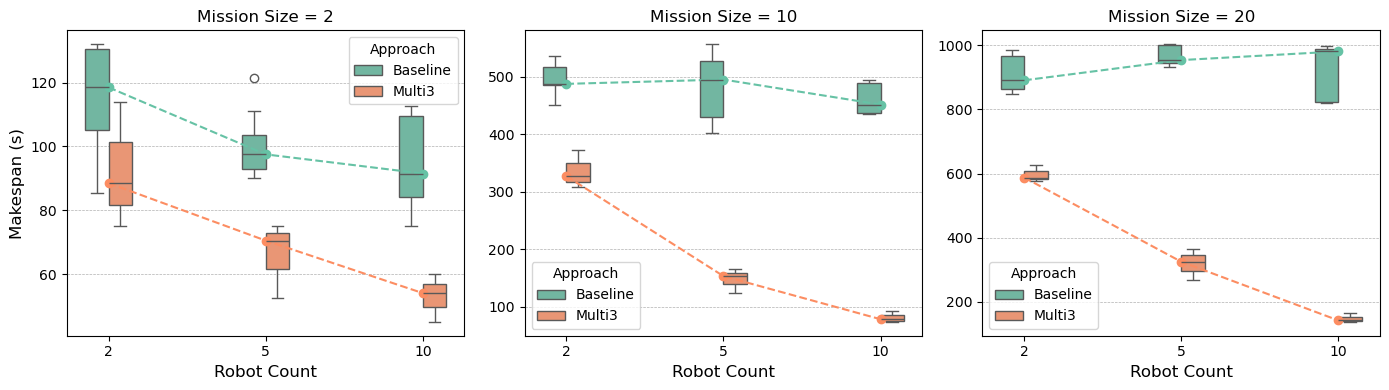

In [10]:
palette = sns.color_palette("Set2")
approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

def multi_box_plot(df,output_file_name, external_variable, var_x, var_y, external_variable_label, x_label, y_label):
    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(14, 4))

    for i, external_variable_value in enumerate(external_variable_values):
        ax = axes[i]
        xx_df = df[df[external_variable] == external_variable_value][[var_x, var_y, "mode"]].copy()
        xx_df["Approach"] = xx_df["mode"].apply(lambda x: "Baseline" if x in {"bl0", "bl1", "bl2"} else "Multi3")

        sns.boxplot(data=xx_df, x=var_x, y=var_y, hue="Approach", palette=approach_colors, width=0.3, ax=ax)

        mission_sizes = sorted(xx_df[var_x].unique())
        x_ticks = range(len(mission_sizes))

        for approach, color in approach_colors.items():
            medians = []
            for size in mission_sizes:
                values = xx_df[(xx_df[var_x] == size) & (xx_df["Approach"] == approach)][var_y]
                if not values.empty:
                    medians.append(np.median(values))
                else:
                    medians.append(np.nan)

            ax.plot(x_ticks, medians, marker="o", linestyle="--", color=color)

        ax.set_title(f"{external_variable_label} = {external_variable_value}")
        ax.set_xlabel(x_label, fontsize=12)
        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")
        ax.yaxis.grid(True, linestyle="--", linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_file_name, format="pdf")
    plt.show()

multi_box_plot(df_mission, "../output/multi-mission/atstart-income/images/ms_by_mission_size_box.pdf", "robot_count", "mission_size", "makespan", "Robot Count", "Mission Size", "Makespan (s)")
multi_box_plot(df_mission, "../output/multi-mission/atstart-income/images/ms_by_robot_count_box.pdf", "mission_size", "robot_count", "makespan", "Mission Size", "Robot Count", "Makespan (s)")

#### Data analysis

Grouping baseline execution and compute average

In [11]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_baseline = df_mission[df_mission["mode"].isin(["bl0", "bl1", "bl2"])]

df_baseline_avg = (
    df_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "makespan": "mean",
        "average_robot_idle_time": "mean"
    })
)

df_baseline_avg["mode"] = "baseline"

df_multi3 = df_mission[df_mission["mode"] == "multi3"].copy()

df_grouped = pd.concat([df_baseline_avg, df_multi3], ignore_index=True)

df_grouped = df_grouped[group_cols + ["mode", "makespan", "average_robot_idle_time"]]
df_grouped

,scenario,robot_count,mission_size,inventory_id,mode,makespan,average_robot_idle_time
0,cleaning,2,2,0,baseline,123.011296,57.000472
1,cleaning,2,2,1,baseline,124.518143,58.767604
2,cleaning,2,2,2,baseline,94.513971,41.509125
3,cleaning,2,10,0,baseline,466.014395,223.755790
4,cleaning,2,10,1,baseline,524.012049,255.438325
5,cleaning,2,10,2,baseline,488.509002,236.144151
6,cleaning,2,20,0,baseline,976.010184,478.827698
7,cleaning,2,20,1,baseline,854.011011,421.234638
8,cleaning,2,20,2,baseline,893.008689,439.510791
9,cleaning,5,2,0,baseline,109.033779,83.437371


Linearizing experiment modes (baseline vs multi3)

In [12]:
pivot_df = df_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["makespan", "average_robot_idle_time"]
)

pivot_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_df.columns]

pivot_df = pivot_df.reset_index()

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "makespan_baseline",
    "makespan_multi3",
    "average_robot_idle_time_baseline",
    "average_robot_idle_time_multi3",
]
pivot_df = pivot_df[ordered_cols]

pivot_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,average_robot_idle_time_baseline,average_robot_idle_time_multi3
0,cleaning,2,2,0,123.011296,88.506254,57.000472,16.515353
1,cleaning,2,2,1,124.518143,114.012098,58.767604,39.015902
2,cleaning,2,2,2,94.513971,75.021153,41.509125,19.520319
3,cleaning,2,10,0,466.014395,327.023574,223.755790,29.268975
4,cleaning,2,10,1,524.012049,372.021868,255.438325,54.012875
5,cleaning,2,10,2,488.509002,307.507225,236.144151,12.769053
6,cleaning,2,20,0,976.010184,576.025526,478.827698,1.510891
7,cleaning,2,20,1,854.011011,588.012671,421.234638,4.527003
8,cleaning,2,20,2,893.008689,628.510760,439.510791,11.258564
9,cleaning,5,2,0,109.033779,75.022339,83.437371,47.211274


#### Computing differences per experiment configuration

In [13]:
makespans_df = pivot_df[["scenario", "robot_count", "mission_size", "inventory_id", "makespan_baseline", "makespan_multi3"]].copy()

makespans_df["makespan_diff_percentage"] = ((makespans_df["makespan_multi3"] - makespans_df["makespan_baseline"]) / makespans_df["makespan_baseline"]) * 100
makespans_df["makespan_paired_diff"] = makespans_df["makespan_baseline"] - makespans_df["makespan_multi3"]

makespans_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,makespan_diff_percentage,makespan_paired_diff
0,cleaning,2,2,0,123.011296,88.506254,-28.050304,34.505042
1,cleaning,2,2,1,124.518143,114.012098,-8.437361,10.506045
2,cleaning,2,2,2,94.513971,75.021153,-20.624271,19.492818
3,cleaning,2,10,0,466.014395,327.023574,-29.825435,138.990821
4,cleaning,2,10,1,524.012049,372.021868,-29.005093,151.990182
5,cleaning,2,10,2,488.509002,307.507225,-37.051882,181.001777
6,cleaning,2,20,0,976.010184,576.025526,-40.981607,399.984659
7,cleaning,2,20,1,854.011011,588.012671,-31.146945,265.998341
8,cleaning,2,20,2,893.008689,628.510760,-29.618741,264.497929
9,cleaning,5,2,0,109.033779,75.022339,-31.193489,34.011440


### Analyzing percentage differences

In [14]:
makespans_stats = (
    makespans_df.groupby(["mission_size", "robot_count"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["mission_size", "robot_count", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,mission_size,robot_count,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,2,-28.050304,-8.437361,-19.037312,-20.624271
1,2,5,-42.633108,-29.865663,-34.564087,-31.193489
2,2,10,-45.911228,-41.587417,-43.622787,-43.369717
3,10,2,-37.051882,-29.005093,-31.960803,-29.825435
4,10,5,-71.765243,-66.562195,-69.550196,-70.323150
5,10,10,-83.756837,-81.068435,-82.302619,-82.082586
6,20,2,-40.981607,-29.618741,-33.915764,-31.146945
7,20,5,-71.450998,-63.488593,-66.987392,-66.022584
8,20,10,-86.069530,-79.756378,-83.776587,-85.503852


In [15]:
makespans_stats = (
    makespans_df.groupby(["mission_size"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["mission_size", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,mission_size,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,-45.911228,-8.437361,-32.408062,-31.193489
1,10,-83.756837,-29.005093,-61.271206,-70.323150
2,20,-86.069530,-29.618741,-61.559914,-66.022584


In [16]:
makespans_stats = (
    makespans_df.groupby(["robot_count"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["robot_count", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,robot_count,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,-40.981607,-8.437361,-28.304626,-29.618741
1,5,-71.765243,-29.865663,-57.033891,-66.022584
2,10,-86.069530,-41.587417,-69.900664,-81.068435


#### Computing average values per scenario

In [17]:
df_completion_average = (
    makespans_df.groupby("scenario")
      .agg({
          "makespan_baseline": "mean",
          "makespan_multi3": "mean",
          "makespan_paired_diff": "mean",
          "makespan_diff_percentage": "mean"
      })
      .reset_index()
)

df_completion_average.rename(columns={"makespan_diff_percentage": "average_of_makespan_diff_percentage"}, inplace=True)

df_completion_average["diff_percentage_on_average_times"] = (df_completion_average["makespan_multi3"] - df_completion_average["makespan_baseline"]) / df_completion_average["makespan_baseline"] * 100

df_completion_average

,scenario,makespan_baseline,makespan_multi3,makespan_paired_diff,average_of_makespan_diff_percentage,diff_percentage_on_average_times
0,cleaning,505.929082,204.743692,301.185391,-51.746394,-59.531148


#### Plotting average completion times per scenario

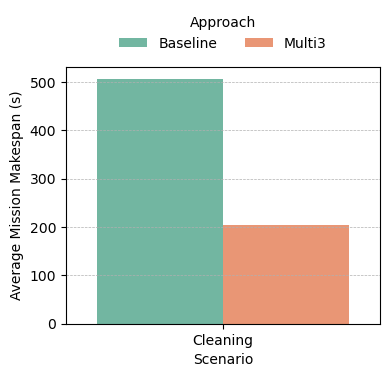

In [18]:
melted = df_completion_average.melt(id_vars='scenario', value_vars=['makespan_baseline', 'makespan_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'makespan_baseline': 'Baseline', 'makespan_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Average Mission Makespan (s)')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/multi-mission/atstart-income/images/ms_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Wilcoxon test on paired differences

In [19]:
## Wilcoxon signed-rank test for makespan differences (on paired samples, to check if the differences are statistically significant, we want to test if multi3 is significantly lower than baseline)
wilcoxon_test = wilcoxon(makespans_df['makespan_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on makespan:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test on makespan:
Statistic: 0.0, p-value: 1.4901161193847656e-08


In [20]:
# Checking only with mission_size = 2
wilcoxon_test_mission_size_2 = wilcoxon(makespans_df[makespans_df['mission_size'] == 2]['makespan_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on makespan(mission_size = 2):\nStatistic: {wilcoxon_test_mission_size_2.statistic}, p-value: {wilcoxon_test_mission_size_2.pvalue}")

Wilcoxon signed-rank test on makespan(mission_size = 2):
Statistic: 0.0, p-value: 0.00390625


In [21]:
median_mission_size = makespans_df['makespan_paired_diff'].median()
percentile_5_mission_size = makespans_df['makespan_paired_diff'].quantile(0.05)

print(f"Makespan paired difference median: {median_mission_size}")
print(f"5th percentile: {percentile_5_mission_size}")

Makespan paired difference median: 265.99834060668945
5th percentile: 22.651906228065492


In [22]:
median_mission_size = makespans_df[makespans_df['mission_size'] == 2]['makespan_paired_diff'].median()
percentile_5_mission_size = makespans_df[makespans_df['mission_size'] == 2]['makespan_paired_diff'].quantile(0.05)

print(f"Makespan paired difference median (mission size = 2): {median_mission_size}")
print(f"5th percentile (mission size = 2): {percentile_5_mission_size}")

Makespan paired difference median (mission size = 2): 34.49262380599975
5th percentile (mission size = 2): 14.100754261016837


## EQ3: Analyzing improvements in idle times

#### Computing idle time ratios per experiment configuration

Metric:

$IdleRatio = \frac{\sum_{r} IdleTime_{r}}{|R| \times CompletionTime}$

where $R$ is the set of robots involved in the mission

In [23]:
idle_times_df = pivot_df[["scenario", "robot_count", "mission_size", "inventory_id", "makespan_baseline", "makespan_multi3", "average_robot_idle_time_baseline", "average_robot_idle_time_multi3"]].copy()

idle_times_df["average_robot_idle_time_diff_percentage"] = (idle_times_df["average_robot_idle_time_multi3"] - idle_times_df["average_robot_idle_time_baseline"]) / idle_times_df["average_robot_idle_time_baseline"] * 100

idle_times_df["idle_ratio_baseline"] = idle_times_df["average_robot_idle_time_baseline"] / idle_times_df["makespan_baseline"]
idle_times_df["idle_ratio_multi3"] = idle_times_df["average_robot_idle_time_multi3"] / idle_times_df["makespan_multi3"]

idle_times_df["idle_ratio_diff_percentage"] = (idle_times_df["idle_ratio_multi3"] - idle_times_df["idle_ratio_baseline"]) / idle_times_df["idle_ratio_baseline"] * 100
idle_times_df["idle_ratio_paired_diff"] = idle_times_df["idle_ratio_baseline"] - idle_times_df["idle_ratio_multi3"]

idle_times_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,average_robot_idle_time_baseline,average_robot_idle_time_multi3,average_robot_idle_time_diff_percentage,idle_ratio_baseline,idle_ratio_multi3,idle_ratio_diff_percentage,idle_ratio_paired_diff
0,cleaning,2,2,0,123.011296,88.506254,57.000472,16.515353,-71.025936,0.463376,0.186601,-59.730110,0.276775
1,cleaning,2,2,1,124.518143,114.012098,58.767604,39.015902,-33.609848,0.471960,0.342208,-27.492094,0.129752
2,cleaning,2,2,2,94.513971,75.021153,41.509125,19.520319,-52.973427,0.439185,0.260198,-40.754468,0.178988
3,cleaning,2,10,0,466.014395,327.023574,223.755790,29.268975,-86.919232,0.480148,0.089501,-81.359674,0.390647
4,cleaning,2,10,1,524.012049,372.021868,255.438325,54.012875,-78.854827,0.487467,0.145187,-70.215930,0.342279
5,cleaning,2,10,2,488.509002,307.507225,236.144151,12.769053,-94.592687,0.483398,0.041524,-91.409889,0.441873
6,cleaning,2,20,0,976.010184,576.025526,478.827698,1.510891,-99.684460,0.490597,0.002623,-99.465354,0.487974
7,cleaning,2,20,1,854.011011,588.012671,421.234638,4.527003,-98.925301,0.493243,0.007699,-98.439142,0.485544
8,cleaning,2,20,2,893.008689,628.510760,439.510791,11.258564,-97.438387,0.492169,0.017913,-96.360377,0.474255
9,cleaning,5,2,0,109.033779,75.022339,83.437371,47.211274,-43.417113,0.765243,0.629296,-17.765213,0.135947


#### Plotting idle ratios for each experimental run

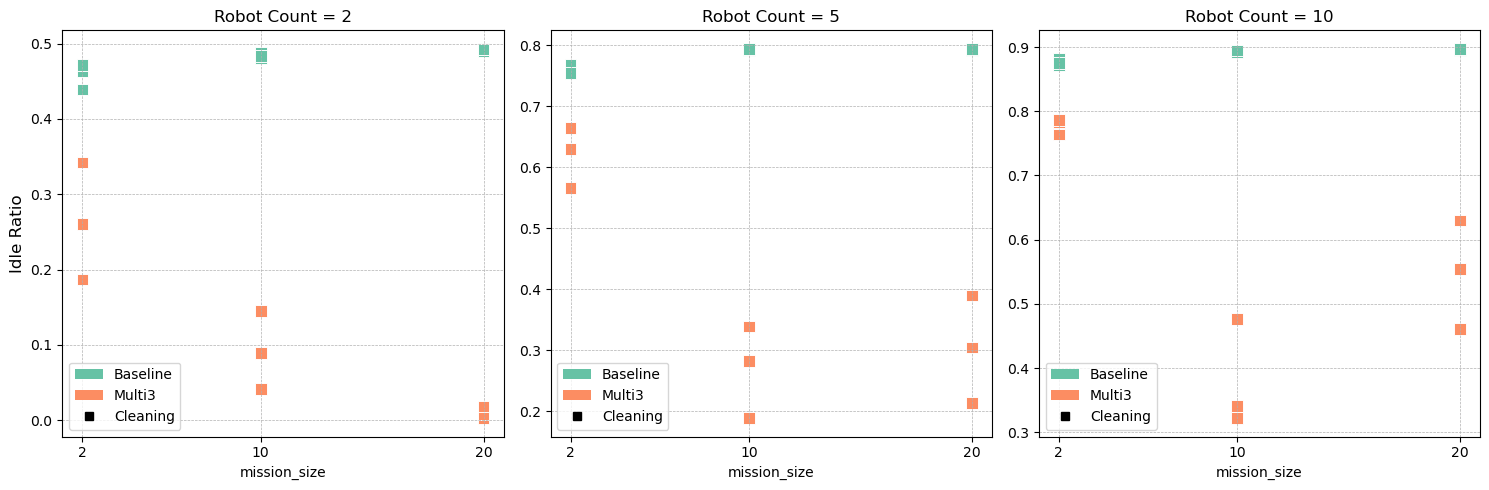

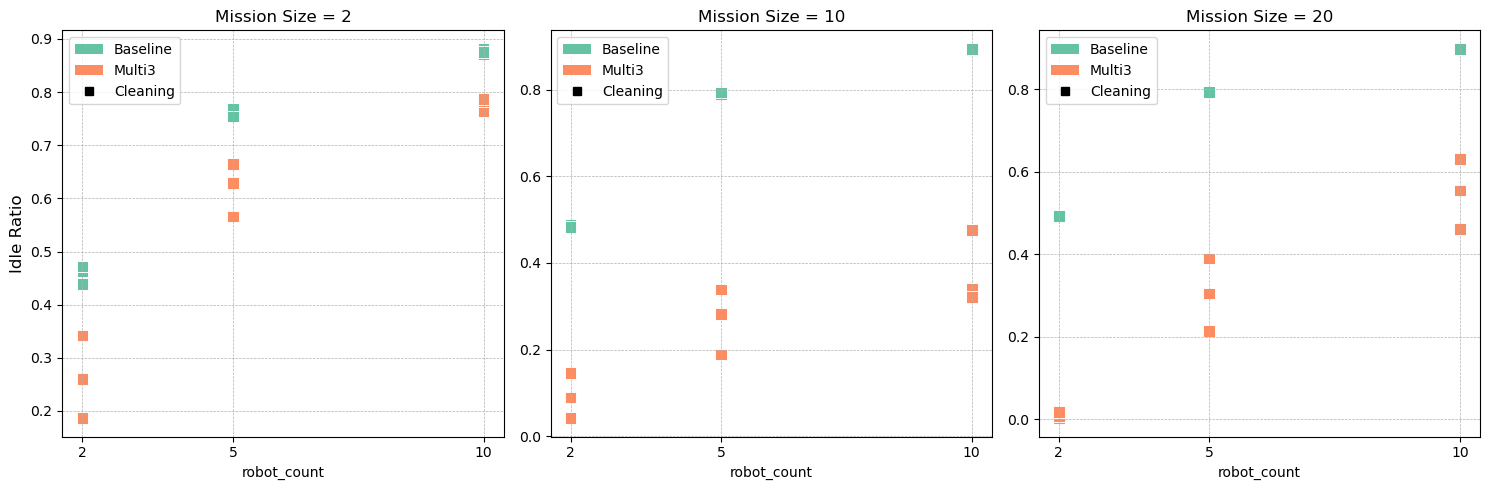

In [24]:
def multiplot_columns(df, fname, external_variable, var_x, baseline_col, multi3_col, title, x_label, y_label):
    marker_dict = {
        "agriculture": "o",
        "cleaning": "s",
        "logistics": "^",
        "surveillance": "D",
        "other": "v"
    }

    palette = sns.color_palette("Set2")
    approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(5 * len(external_variable_values), 5), squeeze=False)
    axes = axes[0]

    for i, v in enumerate(external_variable_values):
        ax = axes[i]

        x_df = df[df[external_variable] == v].copy()

        x_df = x_df.melt(id_vars=[var_x, "scenario", "inventory_id"], value_vars=[baseline_col, multi3_col], var_name="Approach", value_name="metric_value")

        x_df["Approach"] = x_df["Approach"].replace({baseline_col: "Baseline", multi3_col: "Multi3" })

        for approach in ["Baseline", "Multi3"]:
            approach_df = x_df[x_df["Approach"] == approach]

            sns.scatterplot(
                data=approach_df,
                x=var_x,
                y="metric_value",
                style="scenario",
                color=approach_colors[approach],
                ax=ax,
                markers=marker_dict,
                s=70
            )

        ax.set_title(title.replace("$field$", str(v)))
        ax.set_ylabel(y_label, fontsize=12)
        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")
        ax.set_xticks(sorted(x_df[var_x].unique()))
        ax.grid(True, linestyle="--", linewidth=0.5)

        color_handles = [
            Patch(facecolor=approach_colors["Baseline"], label="Baseline"),
            Patch(facecolor=approach_colors["Multi3"], label="Multi3")
        ]

        scenario_values = sorted(df["scenario"].unique())
        marker_handles = [
            Line2D(
                [0], [0],
                marker=marker_dict.get(s, marker_dict["other"]),
                color="black",
                linestyle="None",
                label=s.capitalize()
            )
            for s in scenario_values
        ]

        ax.legend(handles=color_handles + marker_handles, frameon=True)

    plt.tight_layout()
    plt.savefig(fname, format="pdf", bbox_inches="tight")
    plt.show()

multiplot_columns(idle_times_df, "../output/multi-mission/atstart-income/images/ir_by_mission_size_scatter.pdf", "robot_count", "mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "Robot Count = $field$","Mission Size", "Idle Ratio")
multiplot_columns(idle_times_df, "../output/multi-mission/atstart-income/images/ir_by_robot_count_scatter.pdf", "mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "Mission Size = $field$","Robot Count", "Idle Ratio")

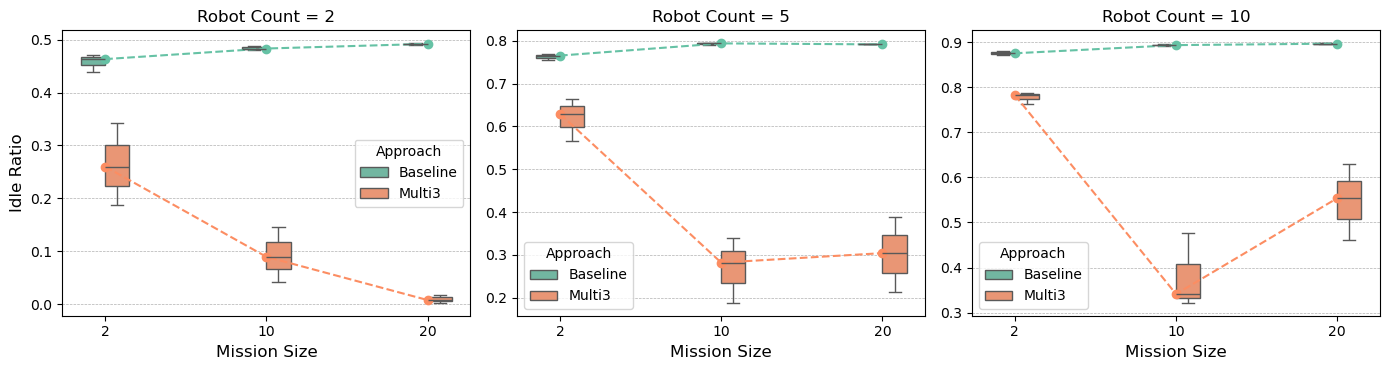

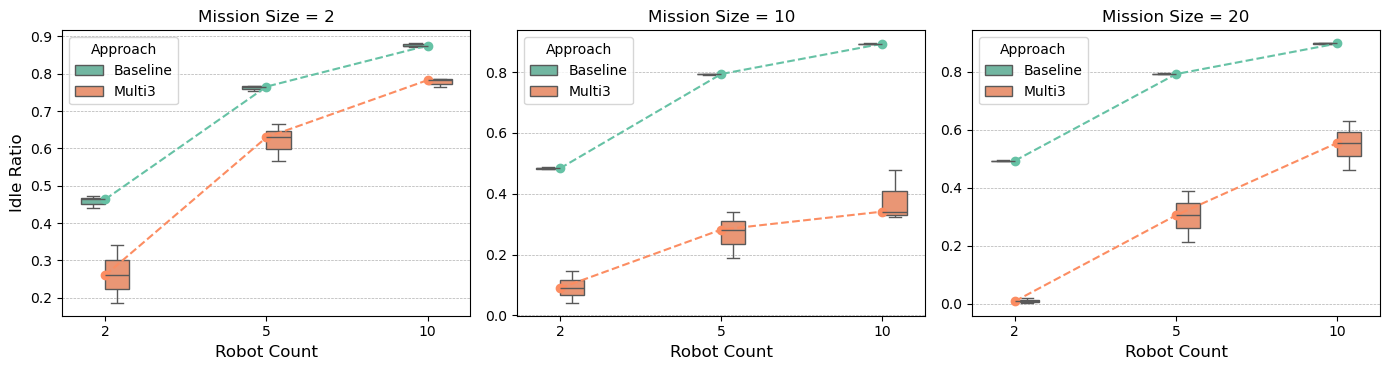

In [25]:
def multi_box_plot_columns(df, output_file_name, external_variable, var_x, baseline_col, multi3_col, external_variable_label, x_label, y_label):
    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(14, 4), squeeze=False)
    axes = axes[0]

    for i, external_variable_value in enumerate(external_variable_values):
        ax = axes[i]

        xx_df = df[df[external_variable] == external_variable_value].copy()
        xx_df = xx_df.melt( id_vars=[var_x], value_vars=[baseline_col, multi3_col], var_name="Approach", value_name="metric_value")
        xx_df["Approach"] = xx_df["Approach"].replace({baseline_col: "Baseline", multi3_col: "Multi3"})

        sns.boxplot(data=xx_df, x=var_x, y="metric_value", hue="Approach", palette=approach_colors, width=0.3, ax=ax)

        var_x_values = sorted(xx_df[var_x].unique())
        x_ticks = range(len(var_x_values))

        for approach, color in approach_colors.items():
            medians = []
            for x_val in var_x_values:
                values = xx_df[
                    (xx_df[var_x] == x_val) &
                    (xx_df["Approach"] == approach)
                ]["metric_value"]

                medians.append(np.median(values) if not values.empty else np.nan)

            ax.plot(x_ticks, medians, marker="o", linestyle="--", color=color)

        ax.set_title(f"{external_variable_label} = {external_variable_value}")
        ax.set_xlabel(x_label, fontsize=12)

        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")

        ax.yaxis.grid(True, linestyle="--", linewidth=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_file_name, format="pdf", bbox_inches="tight")
    plt.show()

multi_box_plot_columns(idle_times_df, "../output/multi-mission/atstart-income/images/ir_by_mission_size_box.pdf", "robot_count", "mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "Robot Count", "Mission Size", "Idle Ratio")
multi_box_plot_columns(idle_times_df, "../output/multi-mission/atstart-income/images/ir_by_robot_count_box.pdf", "mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "Mission Size", "Robot Count", "Idle Ratio")

#### Computing idle time ratio difference percentages per configuration

In [26]:
idle_ratio_stats = (
    idle_times_df.groupby(["mission_size", "robot_count"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,mission_size,robot_count,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,2,0.458174,0.263002,-59.730110,-27.492094,-42.658891,-40.754468
1,2,5,0.762550,0.619818,-24.940341,-13.557419,-18.754324,-17.765213
2,2,10,0.876163,0.777621,-12.399447,-10.159901,-11.248612,-11.186488
3,10,2,0.483671,0.092071,-91.409889,-70.215930,-80.995165,-81.359674
4,10,5,0.792836,0.269599,-76.266481,-57.380539,-65.994270,-64.335790
5,10,10,0.893512,0.379897,-64.021666,-46.663448,-57.481001,-61.757888
6,20,2,0.492003,0.009412,-99.465354,-96.360377,-98.088291,-98.439142
7,20,5,0.791990,0.302389,-73.007690,-50.791053,-61.819156,-61.658725
8,20,10,0.896695,0.548167,-48.657417,-29.762716,-38.865476,-38.176297


In [27]:
idle_ratio_stats = (
    idle_times_df.groupby(["mission_size"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,mission_size,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,0.698962,0.553480,-59.730110,-10.159901,-24.220609,-17.765213
1,10,0.723339,0.247189,-91.409889,-46.663448,-68.156812,-64.335790
2,20,0.726896,0.286656,-99.465354,-29.762716,-66.257641,-61.658725


In [28]:
idle_ratio_stats = (
    idle_times_df.groupby(["robot_count"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,robot_count,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,0.477949,0.121495,-99.465354,-27.492094,-73.914115,-81.359674
1,5,0.782458,0.397269,-76.266481,-13.557419,-48.855917,-57.380539
2,10,0.888790,0.568561,-64.021666,-10.159901,-35.865030,-38.176297


#### Computing idle time ratio averages per scenario

In [29]:
idle_times_average_df = (
    idle_times_df.groupby("scenario")
      .agg({
          "average_robot_idle_time_baseline": "mean",
          "average_robot_idle_time_multi3": "mean",
          "average_robot_idle_time_diff_percentage": "mean",
          "idle_ratio_baseline": "mean",
          "idle_ratio_multi3": "mean",
          "idle_ratio_diff_percentage": "mean"
      })
      .reset_index()
)

idle_times_average_df.rename(columns={"average_robot_idle_time_diff_percentage": "average_of_average_robot_idle_time_diff_percentage", "idle_ratio_diff_percentage": "average_of_idle_ratio_diff_percentage"}, inplace=True)

idle_times_average_df["diff_percentage_on_average_robot_idle_time"] = (idle_times_average_df["average_robot_idle_time_multi3"] - idle_times_average_df["average_robot_idle_time_baseline"]) / idle_times_average_df["average_robot_idle_time_baseline"] * 100

idle_times_average_df["diff_percentage_on_average_ratios"] = (idle_times_average_df["idle_ratio_multi3"] - idle_times_average_df["idle_ratio_baseline"]) / idle_times_average_df["idle_ratio_baseline"] * 100

idle_times_average_df

,scenario,average_robot_idle_time_baseline,average_robot_idle_time_multi3,average_of_average_robot_idle_time_diff_percentage,idle_ratio_baseline,idle_ratio_multi3,average_of_idle_ratio_diff_percentage,diff_percentage_on_average_robot_idle_time,diff_percentage_on_average_ratios
0,cleaning,365.988588,44.143625,-77.09257,0.716399,0.362442,-52.878354,-87.938524,-49.407858


#### Plotting average idle times per scenario

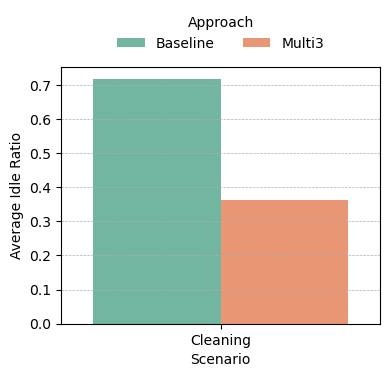

In [30]:
melted = idle_times_average_df.melt(id_vars='scenario', value_vars=['idle_ratio_baseline', 'idle_ratio_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'idle_ratio_baseline': 'Baseline', 'idle_ratio_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Average Idle Ratio')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/multi-mission/atstart-income/images/ir_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Wilcoxon test on paired differences

In [31]:
## Wilcoxon signed-rank test for idle ratio differences (on paired samples, to check if the differences are statistically significant, we want to test if multi3 is significantly lower than baseline)
wilcoxon_test = wilcoxon(idle_times_df['idle_ratio_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on idle ratio:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test on idle ratio:
Statistic: 0.0, p-value: 1.4901161193847656e-08


In [32]:
median_idle_ratio = idle_times_df['idle_ratio_paired_diff'].median()
percentile_5_idle_ratio = idle_times_df['idle_ratio_paired_diff'].quantile(0.05)

print(f"Idle ratio paired difference median: {median_idle_ratio}")
print(f"5th percentile: {percentile_5_idle_ratio}")

Idle ratio paired difference median: 0.4019057255178033
5th percentile: 0.10025409970047776


## EQ4 (first part): Analyzing workload variance

Metric:

$WorkloadVariance = \frac{1}{|R|} \sum_{r \in R}​(W_r ​ − \overline{W})^2$

where: $\overline{W} = \frac{1}{|R|} \sum_{r \in R}​W_r$, and $W_r$ is the active time of robot $r \in R$

$CV = \frac{\sqrt{WorkloadVariance}}{\overline{W}}$

In [33]:
workload_df = mission_data_df.copy()

workload_df["workload"] = workload_df["makespan"] - workload_df["robot_idle_time"]

workload_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,makespan,robot_id,robot_idle_time,workload
0,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_1,432.463462,569.563062
1,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_2,613.922739,388.103785
2,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_3,987.027707,14.998817
3,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_4,957.081356,44.945168
4,test-multi_5_20_t_cleaning_i0_bl2,5,20,0,cleaning,bl2,1002.026524,robot_5,981.072034,20.954491
...,...,...,...,...,...,...,...,...,...,...
607,test-multi_2_10_t_cleaning_i2_bl1,2,10,2,cleaning,bl1,487.509597,robot_2,299.933713,187.575884
608,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,120.020152,robot_1,34.507760,85.512391
609,test-multi_2_2_t_cleaning_i0_bl1,2,2,0,cleaning,bl1,120.020152,robot_2,74.994749,45.025402
610,test-multi_2_20_t_cleaning_i1_multi3,2,20,1,cleaning,multi3,588.012671,robot_1,6.026476,581.986195


In [34]:
group_cols = ["robot_count", "mission_size", "inventory_id", "scenario", "mode"]
workload_variance_df = (
    workload_df
    .groupby(group_cols)
    .agg(
        workload_mean=("workload", "mean"),
        workload_var=("workload", lambda x: x.var(ddof=0)),
        workload_std=("workload", lambda x: x.std(ddof=0))
    )
    .reset_index()
)

workload_variance_df["workload_cv"] = workload_variance_df["workload_std"] / workload_variance_df["workload_mean"]

workload_variance_df

,robot_count,mission_size,inventory_id,scenario,mode,workload_mean,workload_var,workload_std,workload_cv
0,2,2,0,cleaning,bl0,66.002254,2.274890,1.508274,0.022852
1,2,2,0,cleaning,bl1,65.268897,409.799070,20.243495,0.310155
2,2,2,0,cleaning,bl2,66.761323,351.740138,18.754736,0.280922
3,2,2,0,cleaning,multi3,71.990901,8.939910,2.989968,0.041533
4,2,2,1,cleaning,bl0,67.511919,8.984681,2.997446,0.044399
...,...,...,...,...,...,...,...,...,...
103,10,20,1,cleaning,multi3,51.101415,267.926919,16.368473,0.320314
104,10,20,2,cleaning,bl0,84.887248,51706.371951,227.390351,2.678734
105,10,20,2,cleaning,bl1,83.836081,54361.473587,233.155471,2.781087
106,10,20,2,cleaning,bl2,84.431016,54255.372408,232.927827,2.758795


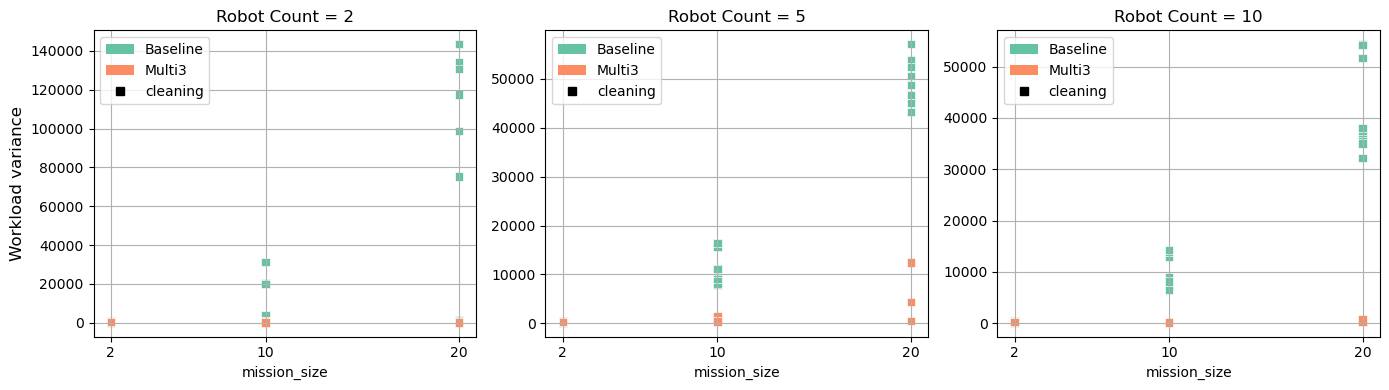

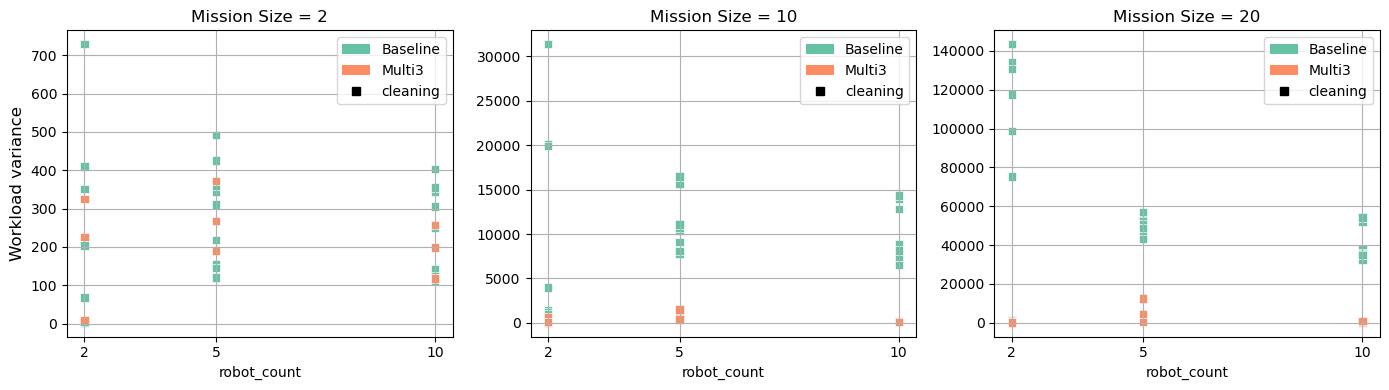

In [35]:
multiplot(workload_variance_df, "../output/multi-mission/atstart-income/images/wv_by_mission_size_scatter.pdf", "robot_count", "mission_size","workload_var","Robot Count = $field$", "Mission Size", "Workload variance")
multiplot(workload_variance_df, "../output/multi-mission/atstart-income/images/wv_by_robot_count_scatter.pdf", "mission_size", "robot_count","workload_var","Mission Size = $field$", "Robot Count", "Workload variance")

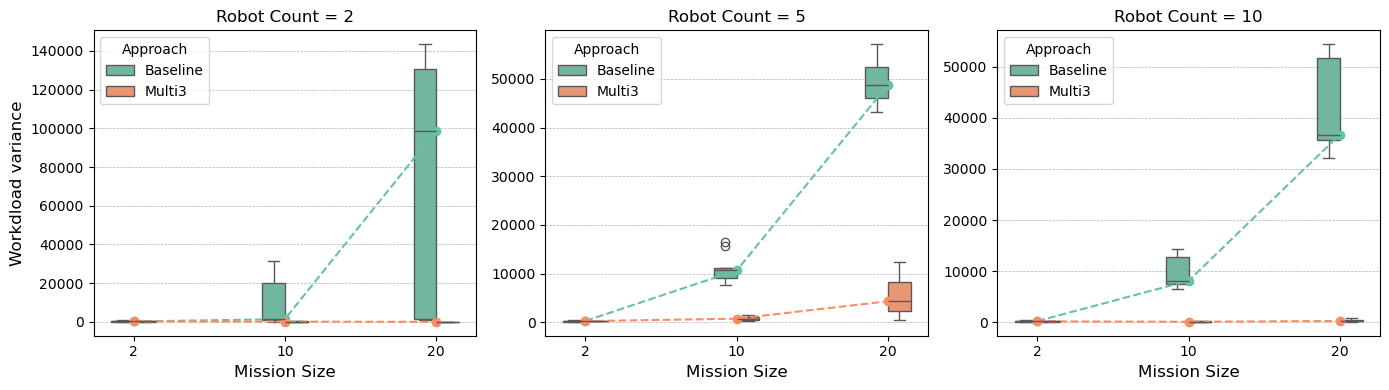

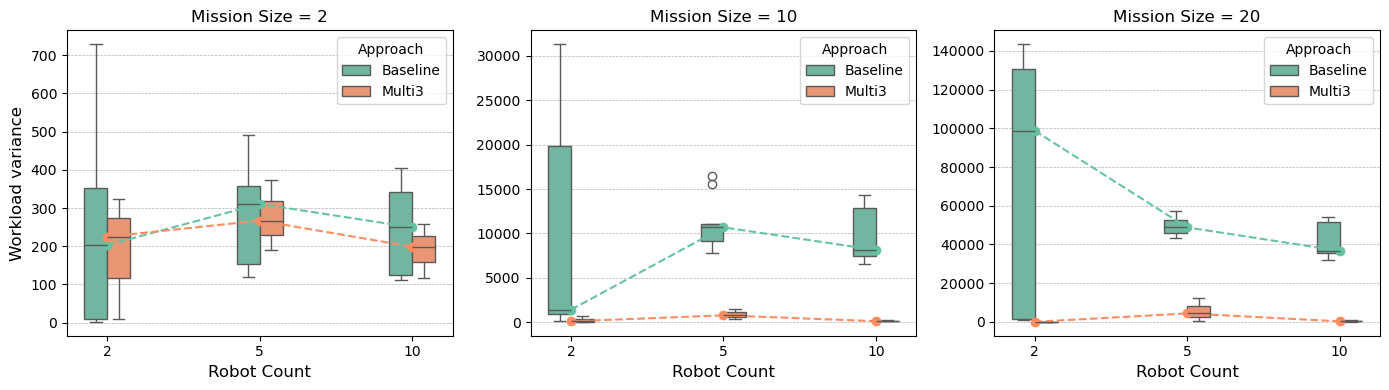

In [36]:
multi_box_plot(workload_variance_df, "../output/multi-mission/atstart-income/images/wv_by_mission_size_box.pdf", "robot_count", "mission_size", "workload_var", "Robot Count", "Mission Size", "Workdload variance")
multi_box_plot(workload_variance_df, "../output/multi-mission/atstart-income/images/wv_by_robot_count_box.pdf", "mission_size", "robot_count", "workload_var", "Mission Size", "Robot Count", "Workload variance")

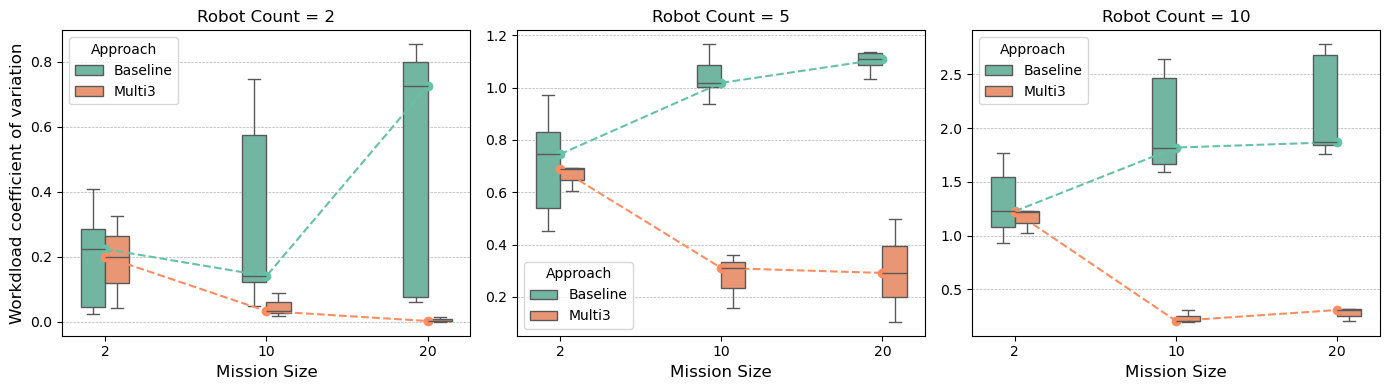

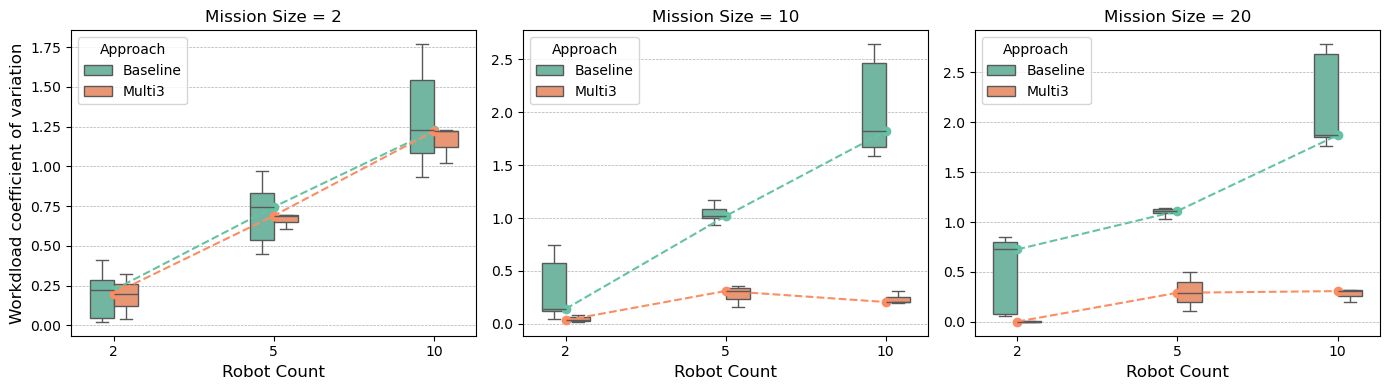

In [37]:
multi_box_plot(workload_variance_df, "../output/multi-mission/atstart-income/images/cv_by_mission_size_box.pdf", "robot_count", "mission_size", "workload_cv", "Robot Count", "Mission Size", "Workdload coefficient of variation")
multi_box_plot(workload_variance_df, "../output/multi-mission/atstart-income/images/cv_by_robot_count_box.pdf", "mission_size", "robot_count", "workload_cv", "Mission Size", "Robot Count", "Workdload coefficient of variation")

In [38]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_workload_baseline = workload_variance_df[workload_variance_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_workload_baseline_avg = (
    df_workload_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "workload_var": "mean",
        "workload_std": "mean",
        "workload_cv": "mean"
    })
)

df_workload_baseline_avg["mode"] = "baseline"

df_workload_multi3 = workload_variance_df[workload_variance_df["mode"] == "multi3"].copy()

df_workload_grouped = pd.concat([df_workload_baseline_avg, df_workload_multi3], ignore_index=True)

df_workload_grouped = df_workload_grouped[group_cols + ["mode", "workload_var", "workload_std", "workload_cv"]]
df_workload_grouped

,scenario,robot_count,mission_size,inventory_id,mode,workload_var,workload_std,workload_cv
0,cleaning,2,2,0,baseline,254.604699,13.502168,0.204643
1,cleaning,2,2,1,baseline,313.675455,14.750037,0.225705
2,cleaning,2,2,2,baseline,99.427915,8.503535,0.161012
3,cleaning,2,10,0,baseline,23766.618789,153.247138,0.633814
4,cleaning,2,10,1,baseline,937.700852,28.511058,0.106254
5,cleaning,2,10,2,baseline,1766.005755,37.753459,0.150062
6,cleaning,2,20,0,baseline,1068.080067,32.489208,0.065352
7,cleaning,2,20,1,baseline,102686.415624,318.249974,0.736019
8,cleaning,2,20,2,baseline,130537.652267,361.000929,0.796132
9,cleaning,5,2,0,baseline,329.135014,17.978299,0.708203


In [39]:
pivot_workload_df = df_workload_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["workload_var", "workload_std", "workload_cv"]
)

pivot_workload_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_workload_df.columns]

pivot_workload_df = pivot_workload_df.reset_index()

pivot_workload_df["workload_var_diff_percentage"] = (
    (pivot_workload_df["workload_var_multi3"] - pivot_workload_df["workload_var_baseline"])
    / pivot_workload_df["workload_var_baseline"]
) * 100

pivot_workload_df["workload_var_paired_diff"] = pivot_workload_df["workload_var_baseline"] - pivot_workload_df["workload_var_multi3"]

pivot_workload_df["workload_cv_diff_percentage"] = (
    (pivot_workload_df["workload_cv_multi3"] - pivot_workload_df["workload_cv_baseline"])
    / pivot_workload_df["workload_cv_baseline"]
) * 100

pivot_workload_df["workload_cv_paired_diff"] = pivot_workload_df["workload_cv_baseline"] - pivot_workload_df["workload_cv_multi3"]

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "workload_var_baseline",
    "workload_var_multi3",
    "workload_var_diff_percentage",
    "workload_var_paired_diff",
    "workload_std_baseline",
    "workload_std_multi3",
    "workload_cv_baseline",
    "workload_cv_multi3",
    "workload_cv_diff_percentage",
    "workload_cv_paired_diff"
]

pivot_workload_df = pivot_workload_df[ordered_cols]

pivot_workload_df

,scenario,robot_count,mission_size,inventory_id,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_var_paired_diff,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage,workload_cv_paired_diff
0,cleaning,2,2,0,254.604699,8.939910,-96.488710,245.664789,13.502168,2.989968,0.204643,0.041533,-79.704870,0.163111
1,cleaning,2,2,1,313.675455,225.166149,-28.216841,88.509306,14.750037,15.005537,0.225705,0.200084,-11.351674,0.025621
2,cleaning,2,2,2,99.427915,324.397149,226.263653,-224.969233,8.503535,18.011029,0.161012,0.324518,101.548687,-0.163506
3,cleaning,2,10,0,23766.618789,688.794757,-97.101840,23077.824032,153.247138,26.244900,0.633814,0.088143,-86.093290,0.545672
4,cleaning,2,10,1,937.700852,35.792082,-96.182996,901.908770,28.511058,5.982648,0.106254,0.018813,-82.294454,0.087441
5,cleaning,2,10,2,1766.005755,94.954805,-94.623188,1671.050950,37.753459,9.744476,0.150062,0.033061,-77.968117,0.117000
6,cleaning,2,20,0,1068.080067,0.000000,-100.000000,1068.080067,32.489208,0.000000,0.065352,0.000000,-100.000000,0.065352
7,cleaning,2,20,1,102686.415624,2.248419,-99.997810,102684.167205,318.249974,1.499473,0.736019,0.002570,-99.650844,0.733449
8,cleaning,2,20,2,130537.652267,67.934578,-99.947958,130469.717689,361.000929,8.242244,0.796132,0.013353,-98.322750,0.782779
9,cleaning,5,2,0,329.135014,372.268657,13.105152,-43.133643,17.978299,19.294265,0.708203,0.693762,-2.039033,0.014440


#### Cleaning from outliers

In [40]:
numeric_cols = pivot_workload_df.select_dtypes(include=np.number).columns
negative_rows = pivot_workload_df[(pivot_workload_df[numeric_cols] > 0).any(axis=1)]
negative_rows

,scenario,robot_count,mission_size,inventory_id,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_var_paired_diff,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage,workload_cv_paired_diff
0,cleaning,2,2,0,254.604699,8.939910,-96.488710,245.664789,13.502168,2.989968,0.204643,0.041533,-79.704870,0.163111
1,cleaning,2,2,1,313.675455,225.166149,-28.216841,88.509306,14.750037,15.005537,0.225705,0.200084,-11.351674,0.025621
2,cleaning,2,2,2,99.427915,324.397149,226.263653,-224.969233,8.503535,18.011029,0.161012,0.324518,101.548687,-0.163506
3,cleaning,2,10,0,23766.618789,688.794757,-97.101840,23077.824032,153.247138,26.244900,0.633814,0.088143,-86.093290,0.545672
4,cleaning,2,10,1,937.700852,35.792082,-96.182996,901.908770,28.511058,5.982648,0.106254,0.018813,-82.294454,0.087441
5,cleaning,2,10,2,1766.005755,94.954805,-94.623188,1671.050950,37.753459,9.744476,0.150062,0.033061,-77.968117,0.117000
6,cleaning,2,20,0,1068.080067,0.000000,-100.000000,1068.080067,32.489208,0.000000,0.065352,0.000000,-100.000000,0.065352
7,cleaning,2,20,1,102686.415624,2.248419,-99.997810,102684.167205,318.249974,1.499473,0.736019,0.002570,-99.650844,0.733449
8,cleaning,2,20,2,130537.652267,67.934578,-99.947958,130469.717689,361.000929,8.242244,0.796132,0.013353,-98.322750,0.782779
9,cleaning,5,2,0,329.135014,372.268657,13.105152,-43.133643,17.978299,19.294265,0.708203,0.693762,-2.039033,0.014440


#### Computing averages per configuration

In [41]:
workload_average_df = (
    pivot_workload_df.groupby(["mission_size", "robot_count"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["mission_size", "robot_count", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,mission_size,robot_count,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,2,222.569356,186.167736,33.852701,0.197120,0.188712,3.497381
1,2,5,285.288964,276.773292,-4.315977,0.694039,0.663435,-4.429284
2,2,10,239.118901,191.228195,-19.840760,1.290915,1.156801,-9.942478
3,10,2,8823.441799,273.180548,-95.969341,0.296710,0.046672,-82.118620
4,10,5,11146.611419,890.446540,-91.309131,1.042711,0.274648,-73.492205
5,10,10,9651.351977,144.246008,-98.337707,2.002515,0.236954,-87.473075
6,20,2,78097.382653,23.394333,-99.981923,0.532501,0.005308,-99.324531
7,20,5,49325.835203,5756.957438,-88.983961,1.103027,0.298076,-73.093509
8,20,10,41499.487916,398.754638,-99.117612,2.140947,0.276622,-86.803253


In [42]:
workload_average_df = (
    pivot_workload_df.groupby(["robot_count"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["robot_count", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,robot_count,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,29047.797936,160.914205,-54.032854,0.342110,0.080231,-59.315257
1,5,20252.578529,2308.059090,-61.536356,0.946592,0.412053,-50.338333
2,10,17129.986265,244.742947,-72.432026,1.811459,0.556792,-61.406269


In [43]:
workload_average_df = (
    pivot_workload_df.groupby(["mission_size"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["mission_size", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,mission_size,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,248.992407,218.056408,3.231988,0.727358,0.669649,-3.624794
1,10,9873.801731,435.957698,-95.205393,1.113979,0.186092,-81.027967
2,20,56307.568591,2059.702136,-96.027832,1.258825,0.193335,-86.407098


#### Computing averages per scenario

In [44]:
workload_average_df = (
    pivot_workload_df.groupby("scenario")
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_std_baseline": "mean",
          "workload_std_multi3": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
      .reset_index()
)

workload_average_df.rename(columns={"workload_var_diff_percentage": "average_of_workload_var_diff_percentage", "workload_cv_diff_percentage": "average_of_workload_cv_diff_percentage"}, inplace=True)

workload_average_df["diff_percentage_on_average_workload_var"] = (workload_average_df["workload_var_multi3"] - workload_average_df["workload_var_baseline"]) / workload_average_df["workload_var_baseline"] * 100
workload_average_df["diff_percentage_on_average_workload_cv"] = (workload_average_df["workload_cv_multi3"] - workload_average_df["workload_cv_baseline"]) / workload_average_df["workload_cv_baseline"] * 100

workload_average_df

,scenario,workload_var_baseline,workload_var_multi3,average_of_workload_var_diff_percentage,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,average_of_workload_cv_diff_percentage,diff_percentage_on_average_workload_var,diff_percentage_on_average_workload_cv
0,cleaning,22143.454243,904.572081,-62.667079,108.958159,20.592719,1.033387,0.349692,-57.019953,-95.914946,-66.160599


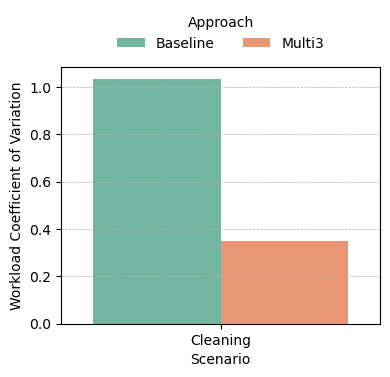

In [45]:
melted = workload_average_df.melt(id_vars='scenario', value_vars=['workload_cv_baseline', 'workload_cv_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'workload_cv_baseline': 'Baseline', 'workload_cv_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Workload Coefficient of Variation')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/multi-mission/atstart-income/images/cv_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Wilcoxon test on paired differences

In [46]:
wilcoxon_test = wilcoxon(pivot_workload_df['workload_var_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on Workload variance:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test on Workload variance:
Statistic: 12.0, p-value: 1.043081283569336e-06


In [47]:
# Checking only with mission_size = 2
wilcoxon_test_mission_size_2 = wilcoxon(pivot_workload_df[pivot_workload_df['mission_size'] == 2]['workload_var_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on Workload variance (mission_size = 2):\nStatistic: {wilcoxon_test_mission_size_2.statistic}, p-value: {wilcoxon_test_mission_size_2.pvalue}")

Wilcoxon signed-rank test on Workload variance (mission_size = 2):
Statistic: 12.0, p-value: 0.25


In [48]:
median_workload_var = pivot_workload_df['workload_var_paired_diff'].median()
percentile_5_workload_var = pivot_workload_df['workload_var_paired_diff'].quantile(0.05)

print(f"Workload variance paired difference median: {median_workload_var}")
print(f"5th percentile: {percentile_5_workload_var}")

Workload variance paired difference median: 7567.869183117074
5th percentile: -30.03740681907214


In [49]:
wilcoxon_test = wilcoxon(pivot_workload_df['workload_cv_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on Workload coefficient of variation:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test on Workload coefficient of variation:
Statistic: 15.0, p-value: 2.041459083557129e-06


In [50]:
median_workload_cv = pivot_workload_df['workload_cv_paired_diff'].median()
percentile_5_workload_cv = pivot_workload_df['workload_cv_paired_diff'].quantile(0.05)

print(f"Workload coefficient of variation paired difference median: {median_workload_cv}")
print(f"5th percentile: {percentile_5_workload_cv}")

Workload coefficient of variation paired difference median: 0.6158940189963302
5th percentile: -0.02167567087407911


In [51]:
# Checking only with mission_size = 2
wilcoxon_test_mission_size_2 = wilcoxon(pivot_workload_df[pivot_workload_df['mission_size'] == 2]['workload_cv_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test on Workload coefficient of variation (mission_size = 2):\nStatistic: {wilcoxon_test_mission_size_2.statistic}, p-value: {wilcoxon_test_mission_size_2.pvalue}")

Wilcoxon signed-rank test on Workload coefficient of variation (mission_size = 2):
Statistic: 12.0, p-value: 0.25


## EQ4 (second part): Analyzing concurrency ratio

## Metric

$CR = \frac{1}{T} \int_0^T A(t)\, dt$,

where $T$ is the mission completion time, and $A(t) = |\{r \in R | r$ is executing a task at time $t\}|$.

In [52]:
with open("../output/multi-mission/atstart-income/robot_data.json", 'r') as f:
    robot_execution_data = json.load(f)

In [53]:
results = []

for mission_id, mission_data in robot_execution_data.items():
    T = mission_data["mission_duration"]
    robots = mission_data["robots"]

    labels = mission_id.split("_")
    robot_count = int(labels[1])
    mission_size = int(labels[2])
    inv_id = int(labels[5][1])
    scenario = labels[4]
    mode = labels[6]

    total_active_time = 0

    for robot_name, robot_data in robots.items():
        intervals = robot_data["non_idle_intervals"]

        robot_active_time = sum(interval[1] for interval in intervals)
        total_active_time += robot_active_time

    cr = total_active_time / T if T > 0 else 0

    results.append({
        "scenario": scenario,
        "robot_count": robot_count,
        "mission_size": mission_size,
        "inventory_id": inv_id,
        "mode": mode,
        "mission_duration": T,
        "total_active_time": total_active_time,
        "CR": cr
    })

concurrency_ratio_df = pd.DataFrame(results)
concurrency_ratio_df

,scenario,robot_count,mission_size,inventory_id,mode,mission_duration,total_active_time,CR
0,cleaning,5,20,0,bl2,1002.026524,1038.565323,1.036465
1,cleaning,10,20,0,multi3,142.504835,635.707717,4.460955
2,cleaning,10,10,0,bl1,489.049393,518.385688,1.059986
3,cleaning,5,10,1,bl2,481.508080,491.592984,1.020944
4,cleaning,10,20,1,bl1,987.053416,1016.908032,1.030246
...,...,...,...,...,...,...,...,...
103,cleaning,10,2,0,bl1,75.033731,97.443311,1.298660
104,cleaning,10,2,0,bl0,79.506199,98.856984,1.243387
105,cleaning,2,10,2,bl1,487.509597,501.236733,1.028158
106,cleaning,2,2,0,bl1,120.020152,130.537794,1.087632


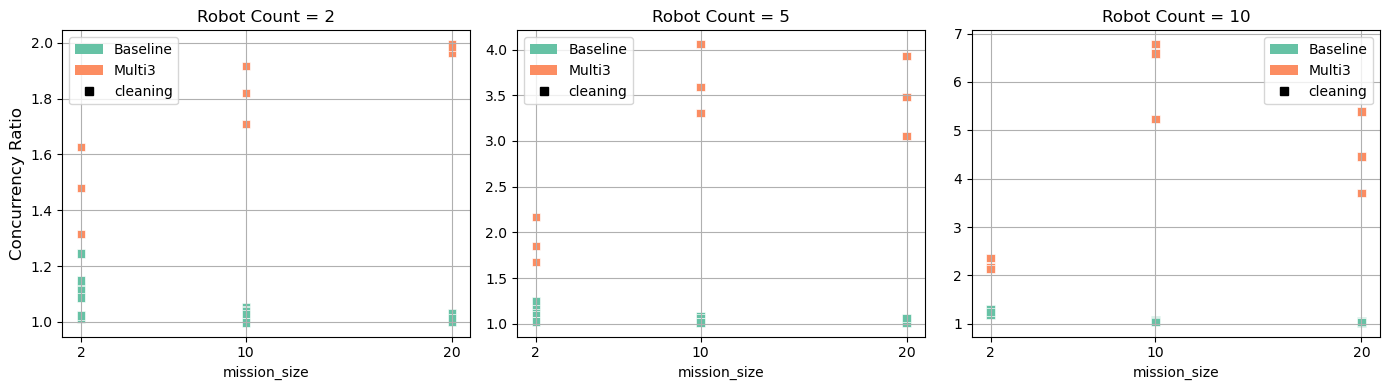

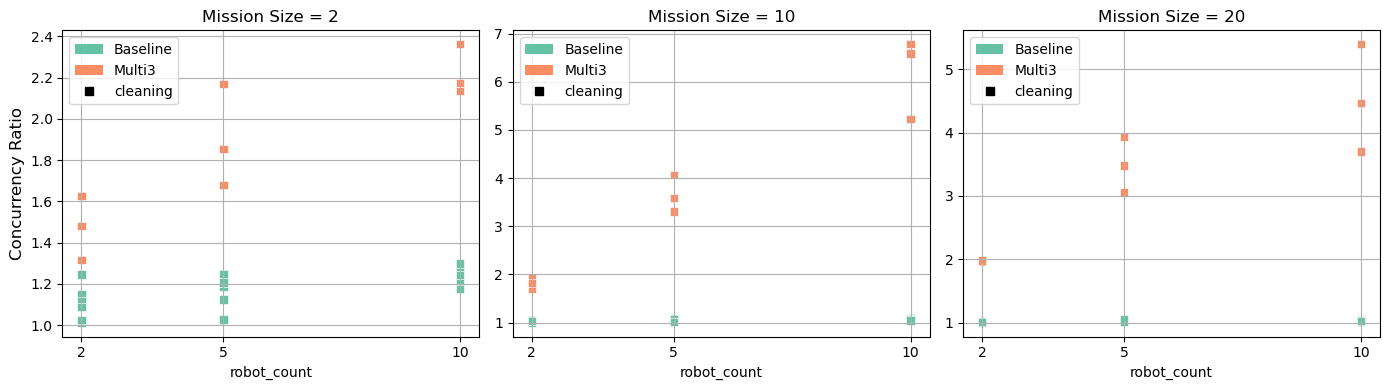

In [54]:
multiplot(concurrency_ratio_df, "../output/multi-mission/atstart-income/images/cr_by_mission_size_scatter.pdf", "robot_count", "mission_size","CR","Robot Count = $field$", "Mission Size", "Concurrency Ratio")
multiplot(concurrency_ratio_df, "../output/multi-mission/atstart-income/images/cr_by_robot_count_scatter.pdf", "mission_size", "robot_count","CR","Mission Size = $field$", "Robot Count", "Concurrency Ratio")

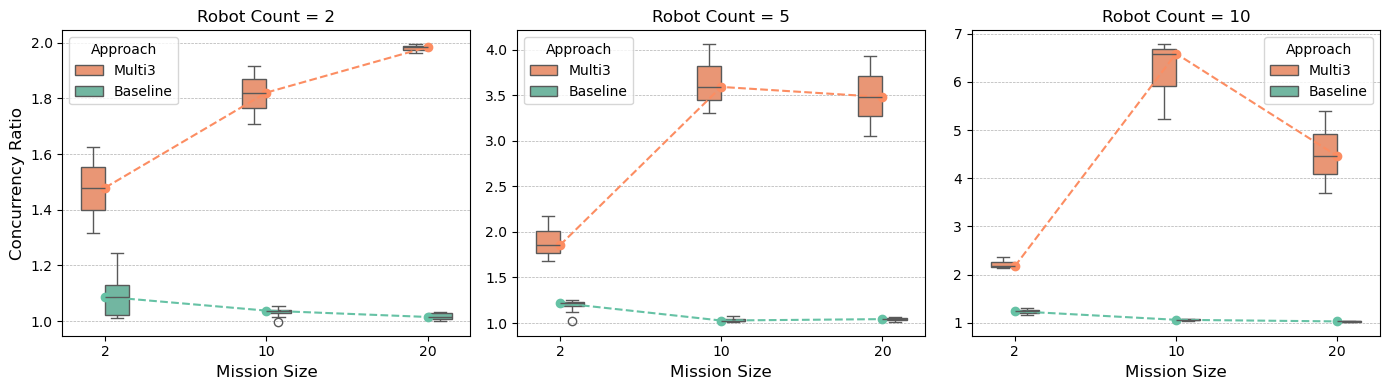

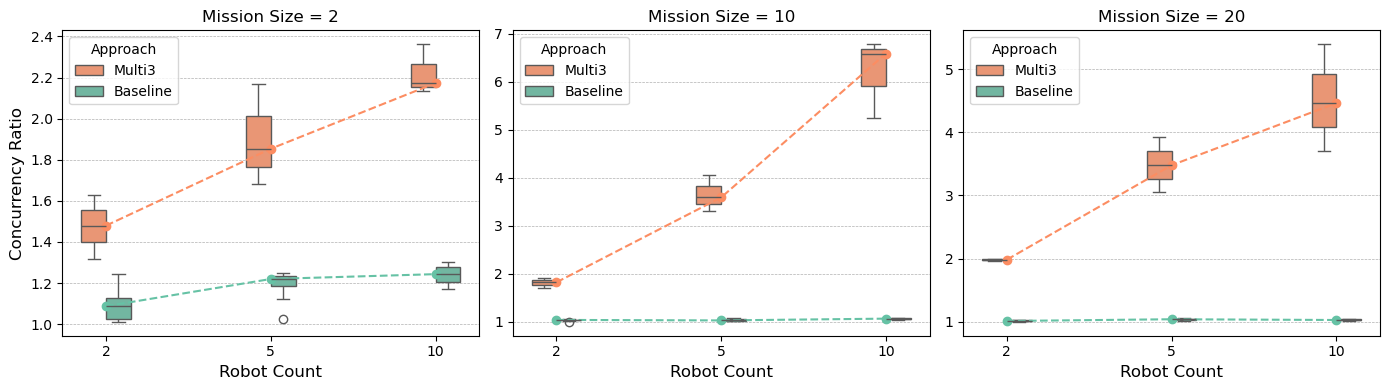

In [55]:
multi_box_plot(concurrency_ratio_df, "../output/multi-mission/atstart-income/images/cr_by_mission_size_box.pdf", "robot_count", "mission_size", "CR", "Robot Count", "Mission Size", "Concurrency Ratio")
multi_box_plot(concurrency_ratio_df, "../output/multi-mission/atstart-income/images/cr_by_robot_count_box.pdf", "mission_size", "robot_count", "CR", "Mission Size", "Robot Count", "Concurrency Ratio")

In [56]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_concurrency_baseline = concurrency_ratio_df[concurrency_ratio_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_concurrency_baseline_avg = (
    df_concurrency_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "mission_duration": "mean",
        "total_active_time": "mean",
        "CR": "mean"
    })
)

df_concurrency_baseline_avg["mode"] = "baseline"

df_concurrency_multi3 = concurrency_ratio_df[concurrency_ratio_df["mode"] == "multi3"].copy()

df_concurrency_grouped = pd.concat([df_concurrency_baseline_avg, df_concurrency_multi3], ignore_index=True)

df_concurrency_grouped = df_concurrency_grouped[group_cols + ["mode", "mission_duration", "total_active_time", "CR"]]
df_concurrency_grouped

,scenario,robot_count,mission_size,inventory_id,mode,mission_duration,total_active_time,CR
0,cleaning,2,2,0,baseline,123.011296,132.021649,1.074880
1,cleaning,2,2,1,baseline,124.518143,131.501079,1.060795
2,cleaning,2,2,2,baseline,94.513971,106.009692,1.129592
3,cleaning,2,10,0,baseline,466.014395,484.517210,1.040238
4,cleaning,2,10,1,baseline,524.012049,537.147448,1.025373
5,cleaning,2,10,2,baseline,488.509002,504.729701,1.033190
6,cleaning,2,20,0,baseline,976.010184,994.364974,1.018884
7,cleaning,2,20,1,baseline,854.011011,865.552746,1.013597
8,cleaning,2,20,2,baseline,893.008689,906.995796,1.015776
9,cleaning,5,2,0,baseline,109.033779,127.982041,1.176927


In [57]:
pivot_concurrency_df = df_concurrency_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["CR"]
)

pivot_concurrency_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_concurrency_df.columns]

pivot_concurrency_df = pivot_concurrency_df.reset_index()

pivot_concurrency_df["CR_diff_percentage"] = (
    (pivot_concurrency_df["CR_multi3"] - pivot_concurrency_df["CR_baseline"])
    / pivot_concurrency_df["CR_baseline"]
) * 100

pivot_concurrency_df["CR_paired_diff"] =pivot_concurrency_df["CR_multi3"] - pivot_concurrency_df["CR_baseline"]

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "CR_baseline",
    "CR_multi3",
    "CR_diff_percentage",
    "CR_paired_diff"
]

pivot_concurrency_df = pivot_concurrency_df[ordered_cols]

pivot_concurrency_df

,scenario,robot_count,mission_size,inventory_id,CR_baseline,CR_multi3,CR_diff_percentage,CR_paired_diff
0,cleaning,2,2,0,1.074880,1.626798,51.346963,0.551918
1,cleaning,2,2,1,1.060795,1.315583,24.018604,0.254788
2,cleaning,2,2,2,1.129592,1.479605,30.985780,0.350013
3,cleaning,2,10,0,1.040238,1.820998,75.055801,0.780759
4,cleaning,2,10,1,1.025373,1.709625,66.732017,0.684252
5,cleaning,2,10,2,1.033190,1.916951,85.537085,0.883761
6,cleaning,2,20,0,1.018884,1.994754,95.778281,0.975870
7,cleaning,2,20,1,1.013597,1.984602,95.798028,0.971006
8,cleaning,2,20,2,1.015776,1.964174,93.366905,0.948398
9,cleaning,5,2,0,1.176927,1.853519,57.488028,0.676592


#### Computing averages per configuration

In [58]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["mission_size", "robot_count"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["mission_size", "robot_count", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,mission_size,robot_count,CR_baseline,CR_multi3,CR_diff_percentage
0,2,2,1.088422,1.473995,35.450449
1,2,5,1.190799,1.900910,59.335267
2,2,10,1.238459,2.223792,79.575051
3,10,2,1.032934,1.815858,75.774968
4,10,5,1.036199,3.652005,252.471768
5,10,10,1.064890,6.201032,482.489251
6,20,2,1.016086,1.981177,94.981071
7,20,5,1.040118,3.488056,235.357931
8,20,10,1.033057,4.518332,337.587419


In [59]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["robot_count"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["robot_count", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,robot_count,CR_baseline,CR_multi3,CR_diff_percentage
0,2,1.045814,1.757010,68.735496
1,5,1.089039,3.013657,182.388322
2,10,1.112135,4.314385,299.883907


In [60]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["mission_size"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["mission_size", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,mission_size,CR_baseline,CR_multi3,CR_diff_percentage
0,2,1.172560,1.866232,58.120256
1,10,1.044674,3.889632,270.245329
2,20,1.029754,3.329188,222.642140


In [61]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["scenario"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.rename(columns={"CR_diff_percentage": "average_of_CR_diff_percentage"}, inplace=True)


concurrency_average_df.columns = ["scenario", "CR_baseline", "CR_multi3", "average_of_CR_diff_percentage"]

concurrency_average_df

,scenario,CR_baseline,CR_multi3,average_of_CR_diff_percentage
0,cleaning,1.082329,3.028351,183.669242


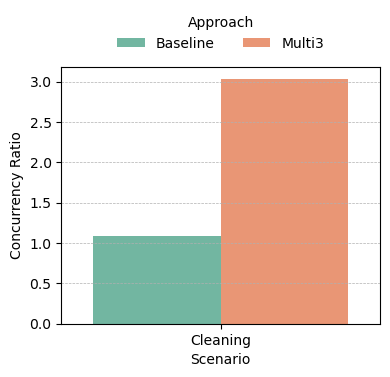

In [62]:
melted = concurrency_average_df.melt(id_vars='scenario', value_vars=['CR_baseline', 'CR_multi3'], var_name='mode', value_name='CR')

melted['mode'] = melted['mode'].replace({'CR_baseline': 'Baseline', 'CR_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='CR', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Concurrency Ratio')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/multi-mission/atstart-income/images/cr_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Wilcoxon test on paired differences

In [63]:
wilcoxon_test = wilcoxon(pivot_concurrency_df['CR_paired_diff'], alternative='two-sided')

print(f"Wilcoxon signed-rank test (on Concurrency Ratio):\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}")

Wilcoxon signed-rank test (on Concurrency Ratio):
Statistic: 0.0, p-value: 1.4901161193847656e-08


In [64]:
median_workload_cv = pivot_concurrency_df['CR_paired_diff'].median()
percentile_5_workload_cv = pivot_concurrency_df['CR_paired_diff'].quantile(0.05)

print(f"Concurrency ratio paired difference median: {median_workload_cv}")
print(f"5th percentile: {percentile_5_workload_cv}")

Concurrency ratio paired difference median: 0.9860086389511782
5th percentile: 0.39909188470667323


## EQ5 Analyzing dynamic mission arrival

$TTFS_m =
        \min_{t \in T_m} \mathit{start}(t)
        -
        \mathit{arrival}(m),
 $


 $MRT_m =
        \max_{t \in T_m} \mathit{end}(t)
        -
        \mathit{arrival}(m)
$

In [65]:
results = []

for mission_id, mission_data in robot_execution_data.items():
    robots = mission_data["robots"]

    labels = mission_id.split("_")
    robot_count = int(labels[1])
    mission_size = int(labels[2])
    inv_id = int(labels[5][1])
    scenario = labels[4]
    mode = labels[6]

    dry_starts = []
    dry_ends = []
    main_starts = []
    main_ends = []

    for robot_name, robot_data in robots.items():
        for interval in robot_data.get("non_idle_intervals", []):
            if len(interval) < 3:
                continue

            start_ts, duration, task_name = interval
            task_name = str(task_name or "").strip()

            if not task_name:
                continue

            # The file stores each interval as [start_timestamp, duration, task_name].
            end_ts = float(start_ts) + float(duration)

            if task_name.lower() == "dry":
                dry_starts.append(float(start_ts))
                dry_ends.append(end_ts)
            else:
                main_starts.append(float(start_ts))
                main_ends.append(end_ts)

    ttfs_main = min(main_starts) if main_starts else np.nan
    ttfs_dry = min(dry_starts) if dry_starts else np.nan
    mrt_main = max(main_ends) if main_ends else np.nan
    mrt_dry = max(dry_ends) if dry_ends else np.nan

    results.append({
        "scenario": scenario,
        "robot_count": robot_count,
        "mission_size": mission_size,
        "inventory_id": inv_id,
        "mode": mode,
        "ttfs_main": ttfs_main,
        "ttfs_dry": ttfs_dry,
        "mrt_main": mrt_main,
        "mrt_dry": mrt_dry
    })

service_times_df = pd.DataFrame(results)
service_times_df

,scenario,robot_count,mission_size,inventory_id,mode,ttfs_main,ttfs_dry,mrt_main,mrt_dry
0,cleaning,5,20,0,bl2,4.514203,4.514203,1002.026524,22.511498
1,cleaning,10,20,0,multi3,4.507224,4.507224,136.506799,22.505391
2,cleaning,10,10,0,bl1,4.506179,4.506179,489.049393,22.509741
3,cleaning,5,10,1,bl2,25.507143,4.506518,481.512385,22.507302
4,cleaning,10,20,1,bl1,4.505433,4.505433,987.053416,22.507066
...,...,...,...,...,...,...,...,...,...
103,cleaning,10,2,0,bl1,4.509470,4.509470,75.033731,22.504486
104,cleaning,10,2,0,bl0,6.073662,4.509224,79.506199,22.513540
105,cleaning,2,10,2,bl1,6.022833,6.022833,487.509597,24.034809
106,cleaning,2,2,0,bl1,6.022416,6.022416,120.020152,24.022416


In [66]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_service_times_baseline = service_times_df[service_times_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_service_times_baseline_avg = (
    df_service_times_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "ttfs_main": "mean",
        "ttfs_dry": "mean",
        "mrt_main": "mean",
        "mrt_dry": "mean",
    })
)

df_service_times_baseline_avg["mode"] = "baseline"

df_service_times_multi3 = service_times_df[service_times_df["mode"] == "multi3"].copy()

df_service_times_grouped = pd.concat([df_service_times_baseline_avg, df_service_times_multi3], ignore_index=True)

df_service_times_grouped = df_service_times_grouped[group_cols + ["mode", "ttfs_main", "ttfs_dry", "mrt_main", "mrt_dry"]]
df_service_times_grouped

,scenario,robot_count,mission_size,inventory_id,mode,ttfs_main,ttfs_dry,mrt_main,mrt_dry
0,cleaning,2,2,0,baseline,13.020403,6.022424,123.011296,24.022805
1,cleaning,2,2,1,baseline,19.519060,5.518936,124.518143,23.516402
2,cleaning,2,2,2,baseline,12.518221,5.517982,94.514983,23.519318
3,cleaning,2,10,0,baseline,12.515386,5.515711,466.014395,23.517391
4,cleaning,2,10,1,baseline,13.019925,5.522137,524.013011,23.519283
5,cleaning,2,10,2,baseline,6.024081,6.024081,488.509002,24.027686
6,cleaning,2,20,0,baseline,20.020377,6.016897,976.010954,24.021987
7,cleaning,2,20,1,baseline,20.021622,6.022078,854.011909,24.020272
8,cleaning,2,20,2,baseline,12.515878,5.515282,893.008689,23.519371
9,cleaning,5,2,0,baseline,5.011339,4.507309,109.034244,22.508707


In [67]:
pivot_service_times_df = df_service_times_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["ttfs_main", "ttfs_dry", "mrt_main", "mrt_dry"]
)

pivot_service_times_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_service_times_df.columns]

pivot_service_times_df = pivot_service_times_df.reset_index()

pivot_service_times_df["ttfs_main_diff_percentage"] = (
    (pivot_service_times_df["ttfs_main_multi3"] - pivot_service_times_df["ttfs_main_baseline"])
    / pivot_service_times_df["ttfs_main_baseline"]
) * 100

pivot_service_times_df["ttfs_dry_diff_percentage"] = (
    (pivot_service_times_df["ttfs_dry_multi3"] - pivot_service_times_df["ttfs_dry_baseline"])
    / pivot_service_times_df["ttfs_dry_baseline"]
) * 100

pivot_service_times_df["ttfs_main_paired_diff"] = pivot_service_times_df["ttfs_main_baseline"] - pivot_service_times_df["ttfs_main_multi3"]
pivot_service_times_df["ttfs_dry_paired_diff"] = pivot_service_times_df["ttfs_dry_baseline"] - pivot_service_times_df["ttfs_dry_multi3"]

pivot_service_times_df["mrt_main_diff_percentage"] = (
    (pivot_service_times_df["mrt_main_multi3"] - pivot_service_times_df["mrt_main_baseline"])
    / pivot_service_times_df["mrt_main_baseline"]
) * 100

pivot_service_times_df["mrt_dry_diff_percentage"] = (
    (pivot_service_times_df["mrt_dry_multi3"] - pivot_service_times_df["mrt_dry_baseline"])
    / pivot_service_times_df["mrt_dry_baseline"]
) * 100

pivot_service_times_df["mrt_main_paired_diff"] = pivot_service_times_df["mrt_main_baseline"] - pivot_service_times_df["mrt_main_multi3"]
pivot_service_times_df["mrt_dry_paired_diff"] = pivot_service_times_df["mrt_dry_baseline"] - pivot_service_times_df["mrt_dry_multi3"]

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "ttfs_main_diff_percentage",
    "ttfs_dry_diff_percentage",
    "ttfs_main_paired_diff",
    "ttfs_dry_paired_diff",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
    "mrt_main_diff_percentage",
    "mrt_dry_diff_percentage",
    "mrt_main_paired_diff",
    "mrt_dry_paired_diff",
]

pivot_service_times_df = pivot_service_times_df[ordered_cols]

pivot_service_times_df

,scenario,robot_count,mission_size,inventory_id,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,ttfs_main_diff_percentage,ttfs_dry_diff_percentage,ttfs_main_paired_diff,ttfs_dry_paired_diff,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3,mrt_main_diff_percentage,mrt_dry_diff_percentage,mrt_main_paired_diff,mrt_dry_paired_diff
0,cleaning,2,2,0,13.020403,6.012002,6.022424,6.012002,-53.826299,-0.173050,7.008401,0.010422,123.011296,88.506254,24.022805,24.013441,-28.050304,-0.038982,34.505042,0.009365
1,cleaning,2,2,1,19.519060,6.013789,5.518936,6.013789,-69.190171,8.966452,13.505271,-0.494853,124.518143,114.012098,23.516402,24.028706,-8.437361,2.178498,10.506045,-0.512304
2,cleaning,2,2,2,12.518221,25.511695,5.517982,4.508814,103.796484,-18.288710,-12.993473,1.009168,94.514983,75.021153,23.519318,22.511631,-20.625121,-4.284510,19.493829,1.007688
3,cleaning,2,10,0,12.515386,27.016840,5.515711,6.024219,115.869003,9.219269,-14.501453,-0.508508,466.014395,327.023574,23.517391,24.024714,-29.825435,2.157224,138.990821,-0.507323
4,cleaning,2,10,1,13.019925,6.023794,5.522137,6.023794,-53.734038,9.084462,6.996131,-0.501656,524.013011,372.024721,23.519283,24.015963,-29.004679,2.111802,151.988290,-0.496681
5,cleaning,2,10,2,6.024081,6.025015,6.024081,6.025015,0.015492,0.015492,-0.000933,-0.000933,488.509002,307.507225,24.027686,24.024400,-37.051882,-0.013676,181.001777,0.003286
6,cleaning,2,20,0,20.020377,4.507917,6.016897,4.507917,-77.483355,-25.079038,15.512460,1.508980,976.010954,576.025526,24.021987,22.511569,-40.981654,-6.287646,399.985428,1.510417
7,cleaning,2,20,1,20.021622,6.026674,6.022078,6.026674,-69.899170,0.076318,13.994947,-0.004596,854.011909,588.012671,24.020272,24.023182,-31.147017,0.012113,265.999238,-0.002910
8,cleaning,2,20,2,12.515878,6.016003,5.515282,6.016003,-51.933031,9.078794,6.499875,-0.500721,893.008689,628.510760,23.519371,24.016913,-29.618741,2.115458,264.497929,-0.497542
9,cleaning,5,2,0,5.011339,4.506904,4.507309,6.039840,-10.065866,34.001024,0.504435,-1.532531,109.034244,75.022339,22.508707,24.030458,-31.193783,6.760719,34.011905,-1.521750


#### Computing averages per configuration

In [68]:
service_times_average_df = (
    pivot_service_times_df.groupby(["mission_size", "robot_count"])
    .agg({
        "ttfs_main_baseline": "mean",
        "ttfs_main_multi3": "mean",
        "ttfs_dry_baseline": "mean",
        "ttfs_dry_multi3": "mean",
        "mrt_main_baseline": "mean",
        "mrt_main_multi3": "mean",
        "mrt_dry_baseline": "mean",
        "mrt_dry_multi3": "mean",
    })
    .reset_index()
)

service_times_average_df.columns = [
    "mission_size",
    "robot_count",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
]

service_times_average_df

,mission_size,robot_count,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3
0,2,2,15.019228,12.512495,5.686447,5.511535,114.014808,92.513169,23.686175,23.517926
1,2,5,7.686143,4.507871,4.676364,5.018849,100.362567,66.011074,22.678071,23.015452
2,2,10,4.683870,4.018516,4.510044,4.508187,94.354811,53.041410,23.175836,23.507291
3,10,2,10.519798,13.021883,5.687310,6.024342,492.845469,335.518507,23.688120,24.021692
4,10,5,18.506838,4.510697,4.507684,4.510697,485.027706,147.522950,22.517572,22.511564
5,10,10,4.508792,4.508643,4.679903,4.508643,459.871032,76.018135,23.678744,24.509066
6,20,2,17.519293,5.516865,5.851419,5.516865,907.677184,597.516319,23.853877,23.517221
7,20,5,7.183204,4.511850,4.679235,4.511850,967.021581,320.020013,22.680872,22.509270
8,20,10,4.851261,4.508763,4.510152,4.508763,932.194282,145.022099,23.174638,23.506793


In [69]:
service_times_average_df = (
    pivot_service_times_df.groupby(["robot_count"])
    .agg({
        "ttfs_main_baseline": "mean",
        "ttfs_main_multi3": "mean",
        "ttfs_dry_baseline": "mean",
        "ttfs_dry_multi3": "mean",
        "mrt_main_baseline": "mean",
        "mrt_main_multi3": "mean",
        "mrt_dry_baseline": "mean",
        "mrt_dry_multi3": "mean",
    })
    .reset_index()
)

service_times_average_df.columns = [
    "robot_count",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
]

service_times_average_df

,robot_count,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3
0,2,14.352773,10.350414,5.741725,5.684247,504.845820,341.849331,23.742724,23.685613
1,5,11.125395,4.510139,4.621094,4.680465,517.470618,177.851345,22.625505,22.678762
2,10,4.681308,4.345307,4.566699,4.508531,495.473375,91.360548,23.343073,23.841050


In [70]:
service_times_average_df = (
    pivot_service_times_df.groupby(["mission_size"])
    .agg({
        "ttfs_main_baseline": "mean",
        "ttfs_main_multi3": "mean",
        "ttfs_dry_baseline": "mean",
        "ttfs_dry_multi3": "mean",
        "mrt_main_baseline": "mean",
        "mrt_main_multi3": "mean",
        "mrt_dry_baseline": "mean",
        "mrt_dry_multi3": "mean",
    })
    .reset_index()
)

service_times_average_df.columns = [
    "mission_size",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
]

service_times_average_df

,mission_size,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3
0,2,9.129747,7.012961,4.957618,5.012857,102.910728,70.521884,23.180027,23.346889
1,10,11.178476,7.347074,4.958299,5.014561,479.248069,186.353197,23.294812,23.680774
2,20,9.851253,4.845826,5.013602,4.845826,935.631016,354.186144,23.236462,23.177762


In [71]:
service_times_average_df = (
    pivot_service_times_df.groupby(["scenario"])
    .agg({
        "ttfs_main_baseline": "mean",
        "ttfs_main_multi3": "mean",
        "ttfs_dry_baseline": "mean",
        "ttfs_dry_multi3": "mean",
        "mrt_main_baseline": "mean",
        "mrt_main_multi3": "mean",
        "mrt_dry_baseline": "mean",
        "mrt_dry_multi3": "mean",
    })
    .reset_index()
)

service_times_average_df.columns = [
    "scenario",
    "ttfs_main_baseline",
    "ttfs_main_multi3",
    "ttfs_dry_baseline",
    "ttfs_dry_multi3",
    "mrt_main_baseline",
    "mrt_main_multi3",
    "mrt_dry_baseline",
    "mrt_dry_multi3",
]

melted = (
    service_times_average_df.melt(
        id_vars="scenario",
        value_vars=[
            "ttfs_main_baseline",
            "ttfs_main_multi3",
            "ttfs_dry_baseline",
            "ttfs_dry_multi3",
            "mrt_main_baseline",
            "mrt_main_multi3",
            "mrt_dry_baseline",
            "mrt_dry_multi3",
        ],
        var_name="metric_mode",
        value_name="value",
    )
)

melted[["metric", "mode"]] = melted["metric_mode"].str.rsplit("_", n=1, expand=True)
melted["mode"] = melted["mode"].replace({"baseline": "Baseline", "multi3": "Multi3"})
melted["metric"] = melted["metric"].replace({
    "ttfs_main": "TTFS Main",
    "ttfs_dry": "TTFS Dry",
    "mrt_main": "MRT Main",
    "mrt_dry": "MRT Dry",
})
melted["scenario"] = melted["scenario"].str.capitalize()

service_times_average_df

,scenario,ttfs_main_baseline,ttfs_main_multi3,ttfs_dry_baseline,ttfs_dry_multi3,mrt_main_baseline,mrt_main_multi3,mrt_dry_baseline,mrt_dry_multi3
0,cleaning,10.053158,6.401954,4.976506,4.957748,505.929938,203.687075,23.2371,23.401808


#### Wilcoxon test on paired differences

In [72]:
for metric in ['ttfs_main', 'ttfs_dry', 'mrt_main', 'mrt_dry']:
    paired_diff = pivot_service_times_df[f'{metric}_paired_diff']
    wilcoxon_test = wilcoxon(paired_diff, alternative='two-sided')
    print(f"Wilcoxon signed-rank test on {metric}:\nStatistic: {wilcoxon_test.statistic}, p-value: {wilcoxon_test.pvalue}\n")

Wilcoxon signed-rank test on ttfs_main:
Statistic: 54.0, p-value: 0.000667765736579895

Wilcoxon signed-rank test on ttfs_dry:
Statistic: 186.0, p-value: 0.9528931677341461

Wilcoxon signed-rank test on mrt_main:
Statistic: 0.0, p-value: 1.4901161193847656e-08

Wilcoxon signed-rank test on mrt_dry:
Statistic: 179.0, p-value: 0.82233826816082

